## Script will investigate the quality control steps of MPRA data
- For each replicate:
  - Corrleation of DNA counts, RNA counts and log2 Ratio (RNA/DNA)
  - Number of barcodes per sequence for each replicate
  - See IGVF
- For known controls
  - correlate with tested 
  - Prio:
    - SLEA: 100 positive and 100 negative
    - Vista: 256 (values given?)
    - neuro specific:
      - C_positive_neuron_CD
      - C_positive_neuron_MK
      - C_positive_neuron_NP
      - C_negative_neuron_MK
      - C_negative_neuron_NP
    - Hon
    - MK
- check which are the sequences with the highest positive 100 and negative 100 effect 

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# load helpful functions
import sys
sys.path.append('/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/00_helpful_functions')
import helpful_functions as hf
# # reload helpful_functions
# from importlib import reload
# reload(hf)

In [2]:
# helpful functions
def combine_replicates(df_allreps, total_dna_counts, total_rna_counts):
    df_allreps = df_allreps.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )
    
    df_allreps = df_allreps.reset_index()
    df_out = df_allreps.iloc[:, 0:2]
    df_out.columns = ["condition", "name"]

    df_out["replicates"] = df_allreps.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = df_allreps.dna_counts["sum"]
    df_out["rna_counts"] = df_allreps.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["log2"] = np.log2(df_out.ratio)

    df_out["mean_dna_counts"] = df_allreps.dna_counts["mean"]
    df_out["mean_rna_counts"] = df_allreps.rna_counts["mean"]
    df_out["mean_dna_normalized"] = df_allreps.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = df_allreps.rna_normalized["mean"]
    df_out["mean_ratio"] = df_allreps.ratio["mean"]
    df_out["mean_log2"] = df_allreps.log2["mean"]
    
    df_out["mean_n_obs_bc"] = df_allreps.n_obs_bc["mean"].apply(int)
    return df_out


def set_modified_chromosome(T_name):
    """i.e. from NC_000001.11 to chr1, ..."""
    if '23' in T_name:
        return 'chrX'
    if '24' in T_name:
        return 'chrY'
    chr_number = int(T_name.split('_')[1].split('.')[0])
    return 'chr%s'%(chr_number) 

### Understanding what the data of NGN2_allreps_minThreshold_merged.combined.tsv.gz is
- /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_minThreshold_merged.tsv.gz
- understand log2 and mean_log2

In [6]:
merged_tsv_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_minThreshold_merged.tsv.gz'
merged_tsv = pd.read_csv(merged_tsv_path, sep='\t')
merged_tsv



,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.039527,0.055928,106
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.320821,1.214635,99
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.132836,0.179939,68
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.216045,0.282196,89
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.014363,0.020575,54
...,...,...,...,...,...,...,...,...,...,...
203590,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.066972,1.047519,75
203591,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.366319,0.450295,26
203592,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.671537,-0.574462,29
203593,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,342,655,0.118881,0.100978,0.887430,-0.172295,104


In [15]:
merged_tsv.groupby(['condition', 'name'])['replicate'].value_counts()

condition  name                                                                                             replicate
NGN2       C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG        1            1
                                                                                                            2            1
                                                                                                            3            1
           C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA  1            1
                                                                                                            2            1
                                                                                                                        ..
           cardiac_neuro_cava_random:ZNF462|ENSG00000148143.13|EH38E3899618_fwd_tile1-1                     2            1
                     

In [16]:
## check count/combine_replicates.py script
df_allreps = merged_tsv.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )

In [17]:
df_allreps

replicate  \
                                                                 count   
condition name                                                           
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
...                                                                ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          no_BC                                                      3   

                                                             dna_counts  \
                                                                    sum   
condition name                                                            
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       1069   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       1140   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        638   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        922   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        595   
...                                                                 ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        631   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        197   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        216   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        946   
          no_BC                                                40574076   

                                                                            \
                                                                      mean   
condition name                                                               
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...  3.563333e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...  3.800000e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  2.126667e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  3.073333e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  1.983333e+02   
...                                                                    ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  2.103333e+02   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  6.566667e+01   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  7.200000e+01   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  3.153333e+02   
          no_BC                                               1.352469e+07   

                                                             rna_counts  \
                                                                    sum   
condition name                                                            
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       2587   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       5188   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       1632   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       2260   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       1412   
...                                                                 ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...       2799   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        646   
          cardiac_neuro_cava_random:ZNF462|ENSG00000148

In [18]:
df_allreps.reset_index()


condition                                               name replicate  \
                                                                       count   
0          NGN2  C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...         3   
1          NGN2  C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...         3   
2          NGN2  C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...         3   
3          NGN2  C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...         3   
4          NGN2  C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...         3   
...         ...                                                ...       ...   
68728      NGN2  cardiac_neuro_cava_random:ZNF462|ENSG000001481...         3   
68729      NGN2  cardiac_neuro_cava_random:ZNF462|ENSG000001481...         3   
68730      NGN2  cardiac_neuro_cava_random:ZNF462|ENSG000001481...         3   
68731      NGN2  cardiac_neuro_cava_random:ZNF462|ENSG000001481...         3   
68732      NGN2                                              no_BC         3   

      dna_counts               rna_counts               dna_normalized  \
             sum          mean        sum          mean           mean   
0           1069  3.563333e+02       2587  8.623333e+02       0.121140   
1           1140  3.800000e+02       5188  1.729333e+03       0.137726   
2            638  2.126667e+02       1632  5.440000e+02       0.116224   
3            922  3.073333e+02       2260  7.533333e+02       0.124520   
4            595  1.983333e+02       1412  4.706667e+02       0.133440   
...          ...           ...        ...           ...            ...   
68728        631  2.103333e+02       2799  9.330000e+02       0.102176   
68729        197  6.566667e+01        646  2.153333e+02       0.099126   
68730        216  7.200000e+01        334  1.113333e+02       0.089462   
68731        946  3.153333e+02       2013  6.710000e+02       0.109184   
68732   40574076  1.352469e+07   92342017  3.078067e+07       0.099242   

      rna_normalized     ratio      log2  n_obs_bc                
                mean      mean      mean       sum          mean  
0           0.126572  1.080802  0.111316       325  1.083333e+02  
1           0.270879  2.040802  1.022238       304  1.013333e+02  
2           0.128225  1.140693  0.189335       202  6.733333e+01  
3           0.132123  1.099769  0.132576       272  9.066667e+01  
4           0.136954  1.060619  0.084120       164  5.466667e+01  
...              ...       ...       ...       ...           ...  
68728       0.195736  1.986678  0.982698       227  7.566667e+01  
68729       0.140391  1.475498  0.558521        73  2.433333e+01  
68730       0.059643  0.690325 -0.539574        89  2.966667e+01  
68731       0.100268  0.952268 -0.072310       319  1.063333e+02  
68732       0.097540  1.015798  0.022542  15041177  5.013726e+06  

[68733 rows x 13 columns]

### Investigate output of MPRAsnakeflow for controls after MPRAsnakeflow
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_minThreshold_merged.combined.tsv.gz`
- 3 replicates; min barcode threshold = 10; min dna and rna = 1

In [3]:
allreps_minthreshold_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_minThreshold_merged.combined.tsv.gz'
allreps_minthreshold_df = pd.read_csv(allreps_minthreshold_path, sep='\t')
# rename column Label to label
allreps_minthreshold_df = allreps_minthreshold_df.rename(columns={'Label': 'label'})

allreps_minthreshold_df

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,3.563333e+02,8.623333e+02,0.121140,0.126572,1.080802,0.111316,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,3.800000e+02,1.729333e+03,0.137726,0.270879,2.040802,1.022238,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,2.126667e+02,5.440000e+02,0.116224,0.128225,1.140693,0.189335,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,3.073333e+02,7.533333e+02,0.124520,0.132123,1.099769,0.132576,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,1.983333e+02,4.706667e+02,0.133440,0.136954,1.060619,0.084120,C_SLEA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68728,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,631,2799,7.766451,14.877391,1.915597,0.937794,2.103333e+02,9.330000e+02,0.102176,0.195736,1.986678,0.982698,cardiac_neuro_cava_random
68729,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,197,646,2.424708,3.433653,1.416110,0.501933,6.566667e+01,2.153333e+02,0.099126,0.140391,1.475498,0.558521,cardiac_neuro_cava_random
68730,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,216,334,2.658563,1.775294,0.667765,-0.582589,7.200000e+01,1.113333e+02,0.089462,0.059643,0.690325,-0.539574,cardiac_neuro_cava_random
68731,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,946,2013,11.643522,10.699603,0.918932,-0.121970,3.153333e+02,6.710000e+02,0.109184,0.100268,0.952268,-0.072310,cardiac_neuro_cava_random


In [4]:
allreps_minthreshold_df['replicates'].value_counts()
# replicates
# 3    66925
# 2     1012
# 1      796
# Name: count, dtype: int64

replicates
3    66925
2     1012
1      796
Name: count, dtype: int64

#### Investigate controls and prepare number table
- for each control group get the number of sequences passed the thresholds


In [9]:
# get controls: 

### Get sequences for Thorben:
- tested:
    - 100 positive
    - 100 negative
    - 200 random
- controls (all neuro positive and negative controls)

In [7]:
# only tested sequences
min_barcodes = 50
min_dna_count = 10
min_rna_count = 10
tested_merged_tsv = merged_tsv.loc[merged_tsv['name'].str.startswith('cardiac_neuro_cava_random')]
print(tested_merged_tsv.shape[0]) # 188825

tested_merged_tsv['count'] = tested_merged_tsv.groupby('name')['name'].transform('count')
# tested_merged_tsv['count'].value_counts()
# count
# 3    186243
# 2      1852
# 1       730
# Name: count, dtype: int64

# quality filter 
# barcode threshold
filtered_tested_merged_tsv = tested_merged_tsv.loc[tested_merged_tsv['n_obs_bc'] > min_barcodes]
print('barcodes: ', filtered_tested_merged_tsv['name'].nunique())

# min dna and rna count
filtered_tested_merged_tsv = filtered_tested_merged_tsv.loc[filtered_tested_merged_tsv['dna_counts'] > min_dna_count]
filtered_tested_merged_tsv = filtered_tested_merged_tsv.loc[filtered_tested_merged_tsv['rna_counts'] > min_rna_count]
print('dna rna counts: ', filtered_tested_merged_tsv['name'].nunique())

# occuring in all 3 replicates: count each name and keep only those with count 3
filtered_tested_merged_tsv['count'] = filtered_tested_merged_tsv.groupby('name')['name'].transform('count')
filtered_tested_merged_tsv = filtered_tested_merged_tsv.loc[filtered_tested_merged_tsv['count'] == 3]
print('replicates: ', filtered_tested_merged_tsv['name'].nunique())


# print shape 
print('After filtering: ', filtered_tested_merged_tsv['name'].nunique()) # 99027 only half of the sequences are left

188825
barcodes:  34553
dna rna counts:  34553


/tmp/ipykernel_1824/2756790659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_merged_tsv['count'] = tested_merged_tsv.groupby('name')['name'].transform('count')


replicates:  31402
After filtering:  31402


In [8]:
filtered_tested_merged_tsv.sort_values(['name', 'replicate']).head()
filtered_tested_merged_tsv['count'].value_counts()

count
3    94206
Name: count, dtype: int64

After filtering merge the sequences over the replicates and sort by log2
Take Top 100 bottom 100 and 200 randomly inbetween

In [9]:
def add_log2_name(row):
    return row['name'] + "__mean_log2_ratio" + str(round(row['mean_log2'], 4))

In [10]:
# merge the sequences over the replicates
total_dna_counts = merged_tsv[["dna_counts"]].sum().iloc[0]
total_rna_counts = merged_tsv[["rna_counts"]].sum().iloc[0]
combined_filtered_df = combine_replicates(filtered_tested_merged_tsv, total_dna_counts, total_rna_counts)
combined_filtered_df['name'].nunique()

# add the mean_log2 to the header
combined_filtered_df['name_mean_log2'] = combined_filtered_df.apply(add_log2_name, axis = 1)

In [11]:
combined_filtered_df[combined_filtered_df['replicates'] != 3]

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_mean_log2


In [12]:
combined_filtered_df.head()

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_mean_log2
0,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,371,376,4.566328,1.998535,0.437668,-1.192092,123.666667,125.333333,0.076498,0.033638,0.467933,-1.115679,59,cardiac_neuro_cava_random:AARS1|ENSG0000009086...
1,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,762,1460,9.378820,7.760268,0.827425,-0.273300,254.000000,486.666667,0.106304,0.087627,0.854852,-0.229034,88,cardiac_neuro_cava_random:AARS1|ENSG0000009086...
2,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,520,994,6.400245,5.283361,0.825494,-0.276671,173.333333,331.333333,0.112053,0.092439,0.853137,-0.231833,57,cardiac_neuro_cava_random:AARS1|ENSG0000009086...
3,NGN2,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,3,1005,1906,12.369704,10.130871,0.819007,-0.288053,335.000000,635.333333,0.126917,0.103887,0.851117,-0.238226,97,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...
4,NGN2,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,3,416,517,5.120196,2.747985,0.536695,-0.897825,138.666667,172.333333,0.087727,0.047301,0.566070,-0.833138,58,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...


In [13]:
# drop unused columns: ('dna_counts', 'rna_counts', 'dna_normalized', 'rna_normalized', 'ratio') 
combined_filtered_final_df = combined_filtered_df.drop(columns=['dna_counts', 'rna_counts', 'dna_normalized', 'rna_normalized', 'ratio'])

# sort by log2
sorted_combined_filtered_df = combined_filtered_final_df.sort_values('mean_log2', ascending=False)

In [14]:
# make 3 sets of variants, then merge
top_x = 100
bottom_x = 100
random_x = 200
seed = 123
top = sorted_combined_filtered_df.head(top_x)
print(top['name'].nunique())
random_inbetween = sorted_combined_filtered_df.head(-bottom_x).tail(-top_x).sample(n=random_x, random_state=123)
print(random_inbetween['name'].nunique())
bottom = sorted_combined_filtered_df.tail(bottom_x)
print(bottom['name'].nunique())

100
200
100


In [15]:
# concat top, random_inbetween and bottom
tested_sequences_filtered_df = pd.concat([top, random_inbetween, bottom])
output_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/07_quality_control/results/ancient_mpra/filtered_tested_sequences.tsv"

tested_sequences_filtered_df.to_csv(output_path, sep="\t", index=False)
tested_sequences_filtered_df

,condition,name,replicates,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_mean_log2
9136,NGN2,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...,3,2.685325,240.666667,3584.666667,0.080954,0.516009,6.708852,2.709582,109,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...
17994,NGN2,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,3,2.583411,335.666667,4658.666667,0.133658,0.801980,6.197491,2.629177,92,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
25773,NGN2,cardiac_neuro_cava_random:REF_LINC01033|ENSG00...,3,2.531441,169.333333,2267.000000,0.079285,0.460838,6.078046,2.583849,78,cardiac_neuro_cava_random:REF_LINC01033|ENSG00...
13495,NGN2,cardiac_neuro_cava_random:ALT_PSMD12|ENSG00000...,3,2.408286,336.333333,4134.333333,0.128581,0.681026,5.465202,2.448528,96,cardiac_neuro_cava_random:ALT_PSMD12|ENSG00000...
4460,NGN2,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,3,2.249515,381.666667,4202.666667,0.139447,0.661118,4.895788,2.284711,100,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...
...,...,...,...,...,...,...,...,...,...,...,...,...
369,NGN2,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,3,-1.438108,149.000000,127.333333,0.085903,0.031903,0.388160,-1.374310,63,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...
27895,NGN2,cardiac_neuro_cava_random:REF_RAF1|ENSG0000013...,3,-1.424313,126.333333,109.000000,0.072566,0.026966,0.386888,-1.376200,64,cardiac_neuro_cava_random:REF_RAF1|ENSG0000013...
19786,NGN2,cardiac_neuro_cava_random:CAPRIN1|ENSG00000135...,3,-1.473755,140.333333,117.000000,0.092818,0.033651,0.381520,-1.402451,55,cardiac_neuro_cava_random:CAPRIN1|ENSG00000135...
33,NGN2,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...,3,-1.470493,121.666667,101.666667,0.079859,0.028893,0.377030,-1.414081,56,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...


#### Investigate how many of these sequences can be matched to the region file

In [26]:
matchable_tested_sequences_path = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/07_quality_control/results/connecting_old_new_design/matchable_tested_sequences.tsv' 
matchable_tested_sequences = pd.read_csv(matchable_tested_sequences_path, sep="\t")
matchable_tested_sequences.head()
print('Number of unique sequences with regions: ', matchable_tested_sequences['name'].nunique())

Number of unique sequences with regions:  73846


In [25]:
# left join of tested_sequences_filtered_df and matchable_tested_sequences
filtered_regions = tested_sequences_filtered_df.merge(matchable_tested_sequences, on="name", how="left")
merged_filtered_regions = filtered_regions[~filtered_regions['name'].isna()]
print(merged_filtered_regions.shape[0]) # 400

output_path = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/07_quality_control/results/ancient_mpra/filtered_tested_regions.tsv'
merged_filtered_regions.to_csv(output_path, sep="\t", index=False)

In [21]:
not_matched_filtered_regions = filtered_regions[filtered_regions['name'].isna()]

##### check if the replicate counts are correct -> yes

In [24]:
tested_merged_tsv[tested_merged_tsv['count'] == 2]['name'].to_list()[0]
# cardiac_neuro_cava_random:ABCC9|ENSG00000069431.14|EH38E1598026_rev_tile1-1

tested_merged_tsv[tested_merged_tsv['name'] == 'cardiac_neuro_cava_random:ABCC9|ENSG00000069431.14|EH38E1598026_rev_tile1-1']


,condition,name,replicates,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,...,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info


#### Investigate threshold

In [22]:
# # plot: per insert
# # question: do I have zero count barcodes?

# dna_thresh = 1
# rna_thresh = 1
# assigned_merged_dir = "/mnt/c/Users/user/OneDrive - Charité - Universitätsmedizin Berlin/Documents/coding/80K_analysis/qc_plots/insert/"
# barcode_dir = "/mnt/c/Users/user/OneDrive - Charité - Universitätsmedizin Berlin/Documents/coding/80K_analysis/qc_plots/barcodes/"
# for replicate_number in ["1", "2", "3"]:
#     assigned_rep = os.path.join(assigned_merged_dir, f"NGN2_{replicate_number}_merged_assigned_counts.tsv.gz")
#     assigned_merged_rep = pd.read_csv(assigned_rep, sep="\t") # rep1: (74688)
#     print(f"For replicate {replicate_number}: ")
#     print(f"number of sequences with less than {dna_thresh} DNA counts", assigned_merged_rep[assigned_merged_rep["dna_counts"] < dna_thresh].shape[0])
#     print(f"number of sequences with less than {rna_thresh} RNA counts", assigned_merged_rep[assigned_merged_rep["rna_counts"] < dna_thresh].shape[0])
# # plot per barcode 

# for replicate_number in ["1", "2", "3"]:
#     barcode_rep = os.path.join(barcode_dir, f"NGN2_{replicate_number}.merged.config.standardConfig.tsv.gz")
#     barcode_rep_df = pd.read_csv(barcode_rep, sep="\t", header=None)
#     barcode_rep_df.columns = ["barcode", "dna_counts", "rna_counts"]
#     print(f"For replicate {replicate_number}: ")
#     print(f"number of sequences with less than {dna_thresh} DNA counts", barcode_rep_df[barcode_rep_df["dna_counts"] < dna_thresh].shape[0])
#     print(f"number of sequences with less than {rna_thresh} RNA counts", barcode_rep_df[barcode_rep_df["rna_counts"] < dna_thresh].shape[0])


### Investigate Element controls
- C_SLEA 200 (100 positive and 100 negative)
- compare to random sequences: GC_DNase_positive_shuffeled (wrong coordinates)
- Vista enhancer
- mendelian variants
- positive_neuron_CD (observed 2 groups: one above 1 and another group below)
  - investigate their correlation

#### Investigate positive neuron Chengyu Deng
- 51 sequences
- check overall correlation: 0.09
- split in two groups and check for the higher group (not really useful)
- check for each replicate individually


In [5]:
def get_ratio_chengyu(header):
    """'C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A::chr4:155359187-155359457-mean_ratio2.42' => 2.42"""
    return float(header.split('mean_ratio')[-1])


def get_ratio_string_chengyu(header):
    """'C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A::chr4:155359187-155359457-mean_ratio2.42' => mean_ratio2.42"""
    return header.split('-')[-1]

def get_ratio_with_underscore(header):
    """
    C_negative_neuron_MK:tile_14444_chr15_67066278_67066547_reference__1.1385203581298 => 1.13852
    C_negative_neuron_NP:GW18_PFC_ABC_chr15_89400286_89400556_0.830617698776558 => 0.8306176
    C_positive_heart_MK:tile_19089_chr18_25285984_25286253_reference_0.325720370916156' => 0.3257
    C_negative_heart_MK:tile_28156_chr3_50600413_50600682_reference__0.107234975260759 => 0.8306176
    """
    return float(header.split('_')[-1])


def plot_correlation(df, column1, column2, name1, name2, title):
    """plot correlation between two columns"""
    # Calculate Pearson correlation coefficient
    pearson_corr = df[column1].corr(df[column2])

    # Plot correlation using Matplotlib's scatter plot
    plt.scatter(df[column1], df[column2])
    plt.xlabel(name1)
    plt.ylabel(name2)
    plt.title(f'{title} ({df.shape[0]}) Pearson Correlation: {pearson_corr:.2f}')
    plt.show()

#### More strict correlation analysis
- increase number of min RNA (~5)
- increase number of minimal barcodes (20-50)
- filter for sequences within replicate values 1,2,3

In [21]:
# filter for >5 RNA counts
merged_tsv # 203595 
merged_tsv.shape[0]

filtered_merged = merged_tsv[merged_tsv["rna_counts"] > 11]
filtered_merged = filtered_merged[filtered_merged["dna_counts"] > 12]
# filtered_merged = merged_tsv[merged_tsv["dna_counts"] > 50]
filtered_merged.shape[0] 
# with rna > 5 and dna > 5 203595 (no loss)
# with rna > 11 and dna > 11 203595 (no loss)
# with rna > 15 and dna > 10 203595 (no loss)
# rna > 20 and dna > 50 183533

# with min rna count > 5 no loss, with min RNA count >30 1k loss (202421) with RNA and DNA count >30 (198779)

203592

In [43]:
# aggregate the replicate tsv 
total_dna_counts = merged_tsv[["dna_counts"]].sum().iloc[0]
total_rna_counts = merged_tsv[["rna_counts"]].sum().iloc[0]

merged_replicates_df = combine_replicates(merged_tsv, total_dna_counts, total_rna_counts)
merged_replicates_df
filtered_merged_replicates_df = combine_replicates(filtered_merged, total_dna_counts, total_rna_counts)
filtered_merged_replicates_df


# # add label
merged_replicates_df['label'] = merged_replicates_df['name'].apply(hf.get_label)
filtered_merged_replicates_df['label'] = filtered_merged_replicates_df['name'].apply(hf.get_label)

### Investigate maximal and minimal results
- merged_replicates all 3 replicates
- highest and lowest with 10, 20, 50 and 100 barcodes


In [97]:
def check_mean_log2(df, n_bcs, top):
    """
    check mean_log2 with the given number of barcodes
    check interval of mean_log2 values max and min 
    check value_counts of label
    """
    filtered_df = df[df['mean_n_obs_bc'] >= n_bcs]
    sorted_df = filtered_df.sort_values(by="mean_log2")
    # sorted_low_100 = sorted_df.head(100)
    # sorted_high_100 = sorted_df.tail(100)
    sorted_low_100 = sorted_df.head(top)
    sorted_high_100 = sorted_df.tail(top)
    print(n_bcs)
    print("Lower table: Min - Max of mean_log2 ", sorted_low_100['mean_log2'].min(), sorted_low_100['mean_log2'].max())
    print(sorted_low_100['label'].value_counts())
    print("High table: Min - Max of mean_log2 ", sorted_high_100['mean_log2'].min(), sorted_high_100['mean_log2'].max())
    print(sorted_high_100['label'].value_counts())

    

In [28]:
merged_3_reps['label'].value_counts()

label
cardiac_neuro_cava_random            62081
MK                                    1950
C_positive_heart_AB                    545
GC_Selvarajan                          309
GC_Vista                               216
GC_Mendelian_variants                  192
GC_Cort_Chengyu                        185
C_negative_heart_MK                    176
C_negative_neuron_MK                   167
C_SLEA                                 160
GC_Kircher                             155
C_negative_neuron_NP                   101
C_positive_neuron_MK                    93
C_positive_heart_CAD                    84
C_positive_heart_MK                     70
GC_GABA_Chengyu                         65
C_positive_neuron_NP                    54
GC_DNase_positive_shuffeled             51
C_positive_neuron_CD                    50
GC_Atrial_fib                           43
GC_DNase_positive                       37
GC_Glut_Chengyu                         31
GC_Mohlke                               29
GC_DN

In [72]:
# load blat results and check if only one perfect match of each sequence
header_names = ['match', 'mismatch', 'rep_match', 'Ns', 'Q_gap_count', 'Q_gap_bases', 'T_gap_count', 'T_gap_bases', 'strand', 'Q_name', 'Q_size', 'Q_start', 'Q_end', 'T_name', 'T_size', 'T_start', 'T_end', 'block_count', 'blockSizes', 'qStarts', 'tStarts']
path_to_blat_results = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/kilian_projects/hg38/ncbi_dataset/data/GCF_000001405.26/blat_variant_control_sequences_matched_file.tsv'
blat_results = pd.read_csv(path_to_blat_results, sep="\t", header=None)
blat_results.columns = header_names
blat_results

# filter: number of matches=270, 
perfect_matches = blat_results[blat_results['match'] == 270]
perfect_matches.shape # 314
# filter for blockSizes = 270
perfect_matches = perfect_matches[perfect_matches['blockSizes'] == '270,']
perfect_matches.shape # 311
# check all columns for unique values and did not find any suspecious values
perfect_matches.T_name.value_counts() # 0 
# filter for matches startwith "NC_" in T_name
perfect_matches = perfect_matches[perfect_matches['T_name'].str.startswith('NC_')]
perfect_matches.shape # 309
perfect_matches.Q_name.nunique() # 309

# get subset of interesting columns
interesting_blat_results = ['Q_name', 'match', 'strand', 'T_name', 'T_start', 'T_end']
interesting_blat_results

perfect_matches = perfect_matches[interesting_blat_results]
perfect_matches

,Q_name,match,strand,T_name,T_start,T_end
0,GC_Atrial_fib:REF_rs74541936|KCNN3|STARR-seq-A...,270,+,NC_000001.11,154813248,154813518
1,GC_Atrial_fib:REF_rs34292822|KCNN3|STARR-seq-A...,270,+,NC_000001.11,154839744,154840014
2,GC_Atrial_fib:REF_rs12754189|KCNN3|STARR-seq-A...,270,+,NC_000001.11,154840018,154840288
3,GC_Atrial_fib:REF_rs36088503|KCNN3|STARR-seq-A...,270,+,NC_000001.11,154840331,154840601
4,GC_Atrial_fib:REF_rs1218584|KCNN3|STARR-seq-AF...,270,+,NC_000001.11,154860467,154860737
...,...,...,...,...,...,...
5563,C_positive_heart_CAD:REF_rs7865618,270,+,NC_000009.12,22030870,22031140
5939,C_positive_heart_CAD:REF_rs4977757,270,+,NC_000009.12,22094195,22094465
6625,C_positive_heart_CAD:REF_rs1537373,270,+,NC_000009.12,22103206,22103476
6626,C_positive_heart_CAD:REF_rs10811656,270,+,NC_000009.12,22124337,22124607


In [73]:
controls_merged_3_reps

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,3.563333e+02,8.623333e+02,0.121140,0.126572,1.080802,0.111316,108,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,3.800000e+02,1.729333e+03,0.137726,0.270879,2.040802,1.022238,101,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,2.126667e+02,5.440000e+02,0.116224,0.128225,1.140693,0.189335,67,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,3.073333e+02,7.533333e+02,0.124520,0.132123,1.099769,0.132576,90,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,1.983333e+02,4.706667e+02,0.133440,0.136954,1.060619,0.084120,54,C_SLEA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4882,NGN2,MK:tile_9894|chr12-94535162+94535431|reference,3,508,4518,6.252547,24.014309,3.840724,1.941378,1.693333e+02,1.506000e+03,0.111408,0.425473,3.973866,1.973436,56,MK
4883,NGN2,MK:tile_9894|chr12-94535162+94535431|ts102-108,3,199,502,2.449324,2.668257,1.089385,0.123514,6.633333e+01,1.673333e+02,0.111033,0.120584,1.124770,0.165880,22,MK
4884,NGN2,MK:tile_9894|chr12-94535162+94535431|ts110-116,3,501,1317,6.166390,7.000187,1.135216,0.182967,1.670000e+02,4.390000e+02,0.117277,0.134168,1.184216,0.238124,52,MK
4885,NGN2,MK:tile_9944|chr12-98489717+98489986|scramble_...,3,679,1668,8.357243,8.865841,1.060857,0.085230,2.263333e+02,5.560000e+02,0.137075,0.145352,1.100841,0.136434,60,MK


In [79]:
def add_regions_to_alternatives(row, alt_ref_dict, current_df):
    """go through alt: ref dict for each name and add the regions of the reference"""
    if row['label'] == 'GC_Selvarajan':
        ref_header = alt_ref_dict[row['name']]
        ref_start = current_df[current_df['Q_name'] == ref_header]['T_start']
        ref_end = current_df[current_df['Q_name'] == ref_header]['T_end']
        chrom = current_df[current_df['Q_name'] == ref_header]['chrom']
        row['chrom'] = chrom
        row['T_start'] = ref_start
        row['T_end'] = ref_end
    return row

In [75]:
perfect_matches['chrom'] = perfect_matches['T_name'].apply(set_modified_chromosome) 
# perfect_matches['label'] = perfect_matches['Q_name'].apply(hf.get_label)
# perfect_matches
# get selvarajan perfect matches

In [82]:
ref_alt_dict = pd.DataFrame(selvarajan_reference_map)
ref_alt_dict

,GC_Selvarajan:ALT_rs10005992|STARR-seq-HepG2_fwd_tile1-1_rs10005992,GC_Selvarajan:ALT_rs1004856|STARR-seq-HepG2_fwd_tile1-1_rs1004856,GC_Selvarajan:ALT_rs10121140|STARR-seq-HepG2~rs10961465|STARR-seq-HepG2_fwd_tile1-3_rs10961465,GC_Selvarajan:ALT_rs10121140|STARR-seq-HepG2~rs10961465|STARR-seq-HepG2_fwd_tile2-3_rs10121140,GC_Selvarajan:ALT_rs10121140|STARR-seq-HepG2~rs10961465|STARR-seq-HepG2_fwd_tile2-3_rs10961465,GC_Selvarajan:ALT_rs10121140|STARR-seq-HepG2~rs10961465|STARR-seq-HepG2_fwd_tile3-3_rs10121140,GC_Selvarajan:ALT_rs10139462|STARR-seq-HepG2~rs4905878|STARR-seq-HepG2_fwd_tile1-3_rs10139462,GC_Selvarajan:ALT_rs10139462|STARR-seq-HepG2~rs4905878|STARR-seq-HepG2_fwd_tile1-3_rs4905878,GC_Selvarajan:ALT_rs10139462|STARR-seq-HepG2~rs4905878|STARR-seq-HepG2_fwd_tile2-3_rs10139462,GC_Selvarajan:ALT_rs10139462|STARR-seq-HepG2~rs4905878|STARR-seq-HepG2_fwd_tile2-3_rs4905878,...,GC_Selvarajan:ALT_rs7933086|STARR-seq-HepG2_fwd_tile1-1_rs7933086,GC_Selvarajan:ALT_rs79341738|STARR-seq-HepG2_fwd_tile1-1_rs79341738,GC_Selvarajan:ALT_rs7949336|STARR-seq-HepG2_fwd_tile1-1_rs7949336,GC_Selvarajan:ALT_rs832410|STARR-seq-HepG2_fwd_tile1-1_rs832410,GC_Selvarajan:ALT_rs907463|STARR-seq-HepG2_fwd_tile1-1_rs907463,GC_Selvarajan:ALT_rs9606016|STARR-seq-HepG2_fwd_tile1-1_rs9606016,GC_Selvarajan:ALT_rs965823|STARR-seq-HepG2_fwd_tile1-1_rs965823,GC_Selvarajan:ALT_rs9660819|STARR-seq-HepG2~rs9661525|STARR-seq-HepG2_fwd_tile1-1_rs9660819,GC_Selvarajan:ALT_rs9660819|STARR-seq-HepG2~rs9661525|STARR-seq-HepG2_fwd_tile1-1_rs9661525,GC_Selvarajan:ALT_rs998089|STARR-seq-HepG2_fwd_tile1-1_rs998089
0,GC_Selvarajan:REF_rs10005992|STARR-seq-HepG2_f...,GC_Selvarajan:REF_rs1004856|STARR-seq-HepG2_fw...,GC_Selvarajan:REF_rs10121140|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10121140|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10121140|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10121140|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10139462|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10139462|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10139462|STARR-seq-HepG2~r...,GC_Selvarajan:REF_rs10139462|STARR-seq-HepG2~r...,...,GC_Selvarajan:REF_rs7933086|STARR-seq-HepG2_fw...,GC_Selvarajan:REF_rs79341738|STARR-seq-HepG2_f...,GC_Selvarajan:REF_rs7949336|STARR-seq-HepG2_fw...,GC_Selvarajan:REF_rs832410|STARR-seq-HepG2_fwd...,GC_Selvarajan:REF_rs907463|STARR-seq-HepG2_fwd...,GC_Selvarajan:REF_rs9606016|STARR-seq-HepG2_fw...,GC_Selvarajan:REF_rs965823|STARR-seq-HepG2_fwd...,GC_Selvarajan:REF_rs9660819|STARR-seq-HepG2~rs...,GC_Selvarajan:REF_rs9660819|STARR-seq-HepG2~rs...,GC_Selvarajan:REF_rs998089|STARR-seq-HepG2_fwd...


In [83]:
merged_controls_region

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,...,mean_log2,mean_n_obs_bc,label,Q_name,match,strand,T_name,T_start,T_end,chrom
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,3.563333e+02,...,0.111316,108,C_SLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,3.800000e+02,...,1.022238,101,C_SLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,2.126667e+02,...,0.189335,67,C_SLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,3.073333e+02,...,0.132576,90,C_SLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,1.983333e+02,...,0.084120,54,C_SLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4732,NGN2,MK:tile_9894|chr12-94535162+94535431|reference,3,508,4518,6.252547,24.014309,3.840724,1.941378,1.693333e+02,...,1.973436,56,MK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4733,NGN2,MK:tile_9894|chr12-94535162+94535431|ts102-108,3,199,502,2.449324,2.668257,1.089385,0.123514,6.633333e+01,...,0.165880,22,MK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4734,NGN2,MK:tile_9894|chr12-94535162+94535431|ts110-116,3,501,1317,6.166390,7.000187,1.135216,0.182967,1.670000e+02,...,0.238124,52,MK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4735,NGN2,MK:tile_9944|chr12-98489717+98489986|scramble_...,3,679,1668,8.357243,8.865841,1.060857,0.085230,2.263333e+02,...,0.136434,60,MK,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:

# merge with variant_region_map 



# merged_controls_selvarajan =  merged_controls_region[~merged_controls_region['T_start'].isna()]
# merged_controls_selvarajan['label'].value_counts()
# # # iterate selvarajan_reference_map and add for the list of alternatives 
# test_merged_with_alternative_regions = merged_controls_region.apply(add_regions_to_alternatives, args=(selvarajan_reference_map, perfect_matches),axis=1)
# test_merged_with_alternative_regions



# merged_controls_region    

# focus on GC_Selvarajan combine all regions of references to the corresponding alternative


 
# filtered_df = merged_controls_region[merged_controls_region['mean_n_obs_bc'] >= 50]
# sorted_df = filtered_df.sort_values(by="mean_log2")
# sorted_low_100 = sorted_df.head(100)
# sorted_high_100 = sorted_df.tail(100)
# sorted_low_100_with_region = sorted_low_100[sorted_low_100['label'] == 'GC_Selvarajan']
# sorted_low_100_with_region
# filtered_df = test_merged_with_alternative_regions[test_merged_with_alternative_regions['mean_n_obs_bc'] >= 50]
# sorted_df = filtered_df.sort_values(by="mean_log2")
# sorted_low_100 = sorted_df.head(100)
# sorted_high_100 = sorted_df.tail(100)
# sorted_low_100_with_region = sorted_low_100[sorted_low_100['label'] == 'GC_Selvarajan']
# sorted_low_100_with_region

169


In [101]:
# merged_3_reps = merged_replicates_df[merged_replicates_df['replicates'] == 3]
merged_3_reps = filtered_merged_replicates_df[merged_replicates_df['replicates'] == 3]
merged_3_reps


controls_merged_3_reps = merged_3_reps[merged_3_reps['label'] != 'cardiac_neuro_cava_random']
controls_merged_3_reps['label'].value_counts()
check_mean_log2(merged_3_reps, 20, 20)
check_mean_log2(merged_3_reps, 50, 20)
check_mean_log2(merged_3_reps, 100, 20)
check_mean_log2(merged_3_reps, 20, 100)
check_mean_log2(merged_3_reps, 50, 100)
check_mean_log2(merged_3_reps, 100, 100)
# merge matched regions and controls





# 50
# Lower table: Min - Max of mean_log2  -1.5174509266666665 -0.7501343966666667
# label
# MK                             26
# C_negative_neuron_MK           16
# C_negative_neuron_NP           13
# C_negative_heart_MK            13
# GC_Selvarajan                  13
# GC_Mendelian_variants           7
# C_positive_heart_AB             7
# GC_DNase_positive_shuffeled     3
# C_positive_heart_CAD            1
# GC_Vista                        1
# Name: count, dtype: int64
# High table: Min - Max of mean_log2  1.7868482066666667 3.572338953333334
# label
# MK                      62
# C_positive_neuron_MK    21
# C_positive_neuron_NP    13
# C_positive_heart_MK      2
# GC_GABA_Chengyu          1
# C_positive_heart_AB      1
# Name: count, dtype: int64




# controls: 
check_mean_log2(controls_merged_3_reps, 20, 20)
check_mean_log2(controls_merged_3_reps, 50, 20)
check_mean_log2(controls_merged_3_reps, 100, 20)

# n_bcs = 10
# merged_3_reps_mean_bcs_10 = merged_3_reps[merged_3_reps['mean_n_obs_bc'] >= n_bcs]
# n_bcs = 20
# merged_3_reps_mean_bcs_20 = merged_3_reps[merged_3_reps['mean_n_obs_bc'] >= n_bcs]

# n_bcs = 50
# merged_3_reps_mean_bcs_50 = merged_3_reps[merged_3_reps['mean_n_obs_bc'] >= n_bcs]
# n_bcs = 100
# merged_3_reps_mean_bcs_100 = merged_3_reps[merged_3_reps['mean_n_obs_bc'] >= n_bcs]

# mean_log2_sorted = merged_3_reps_mean_bcs_10.sort_values(by='mean_log2')
# mean_log2_sorted.head(100) # -1.94 - -1.46
# mean_log2_sorted = merged_3_reps_mean_bcs_20.sort_values(by='mean_log2')
# mean_log2_sorted.head(100) # -1.79 - -1.39
# mean_log2_sorted = merged_3_reps_mean_bcs_50.sort_values(by='mean_log2')
# mean_log2_sorted.head(100) # -1.53 - -1.17
# mean_log2_sorted = merged_3_reps_mean_bcs_100.sort_values(by='mean_log2')
# mean_log2_sorted.head(100) # -1.27 - - 0.83

20
Lower table: Min - Max of mean_log2  -1.7894338533333334 -1.6044482666666668
label
cardiac_neuro_cava_random    17
C_positive_heart_AB           1
GC_DNase_positive             1
C_negative_neuron_MK          1
Name: count, dtype: int64
High table: Min - Max of mean_log2  2.74697984 4.146284223333333
label
MK                           10
C_positive_neuron_NP          5
cardiac_neuro_cava_random     3
C_positive_neuron_MK          1
C_positive_heart_MK           1
Name: count, dtype: int64
50
Lower table: Min - Max of mean_log2  -1.5298541233333334 -1.32309217
label
cardiac_neuro_cava_random    15
C_negative_neuron_NP          4
C_positive_heart_CAD          1
Name: count, dtype: int64
High table: Min - Max of mean_log2  2.578636616666667 3.572338953333334
label
MK                           6
C_positive_neuron_NP         5
C_positive_neuron_MK         4
cardiac_neuro_cava_random    3
C_positive_heart_MK          2
Name: count, dtype: int64
100
Lower table: Min - Max of mean_log2  -1.

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-58/ipykernel_2296729/344755754.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  merged_3_reps = filtered_merged_replicates_df[merged_replicates_df['replicates'] == 3]


In [86]:
controls_merged_3_reps

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,3.563333e+02,8.623333e+02,0.121140,0.126572,1.080802,0.111316,108,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,3.800000e+02,1.729333e+03,0.137726,0.270879,2.040802,1.022238,101,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,2.126667e+02,5.440000e+02,0.116224,0.128225,1.140693,0.189335,67,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,3.073333e+02,7.533333e+02,0.124520,0.132123,1.099769,0.132576,90,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,1.983333e+02,4.706667e+02,0.133440,0.136954,1.060619,0.084120,54,C_SLEA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4882,NGN2,MK:tile_9894|chr12-94535162+94535431|reference,3,508,4518,6.252547,24.014309,3.840724,1.941378,1.693333e+02,1.506000e+03,0.111408,0.425473,3.973866,1.973436,56,MK
4883,NGN2,MK:tile_9894|chr12-94535162+94535431|ts102-108,3,199,502,2.449324,2.668257,1.089385,0.123514,6.633333e+01,1.673333e+02,0.111033,0.120584,1.124770,0.165880,22,MK
4884,NGN2,MK:tile_9894|chr12-94535162+94535431|ts110-116,3,501,1317,6.166390,7.000187,1.135216,0.182967,1.670000e+02,4.390000e+02,0.117277,0.134168,1.184216,0.238124,52,MK
4885,NGN2,MK:tile_9944|chr12-98489717+98489986|scramble_...,3,679,1668,8.357243,8.865841,1.060857,0.085230,2.263333e+02,5.560000e+02,0.137075,0.145352,1.100841,0.136434,60,MK


In [93]:
# merge regions from references to alternatives

variant_region_map_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/unifying_headers_kilian_042024/variant_map_with_unified_headers_mendelian_focus.tsv'
variant_region_map = pd.read_csv(variant_region_map_path, sep='\t')


## go through all references and get list of variants for each reference
variant_region_map = variant_region_map[variant_region_map['REF_ID'].str.startswith('GC_Selvarajan')]
variant_region_map.groupby('REF_ID')['ALT_ID'].apply(list).reset_index(name='alternatives')
selvarajan_reference_map = variant_region_map.groupby('ALT_ID')['REF_ID'].apply(list).to_dict()
selvarajan_reference_map

variant_region_map_minimized = variant_region_map[['REF_ID', 'ALT_ID']]
variant_region_map_minimized


# merge position and controls
merged_controls_region = controls_merged_3_reps.merge(variant_region_map_minimized, left_on='name', right_on="REF_ID", how='left')
merged_controls_region 
merged_controls_ref_regions = merged_controls_region.merge(perfect_matches, left_on='REF_ID', right_on='Q_name', how='left')
merged_controls_ref = merged_controls_region[~merged_controls_region['REF_ID'].isna()]# 169
print(merged_controls_ref.shape[0])

merged_controls_ref_regions = merged_controls_ref_regions[~merged_controls_ref_regions['chrom'].isna()]



169


169

In [ ]:
perfect_match_blat_labels

In [94]:
perfect_match_blat_labels = perfect_matches['Q_name'].apply(hf.get_label)
perfect_match_blat_labels.value_counts()

Q_name
GC_Selvarajan            165
C_positive_heart_CAD      48
GC_Mendelian_variants     46
GC_Atrial_fib             21
GC_Mohlke                 16
GC_Liang                   8
GC_Kircher                 5
Name: count, dtype: int64

In [91]:
merged_controls_ref['T_name']

KeyError: 'T_name'

51


/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-58/ipykernel_2296729/2167239768.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chengyu_positive_3_reps_mean_bcs['given_ratio'] = chengyu_positive_3_reps_mean_bcs['name'].apply(get_ratio_chengyu)


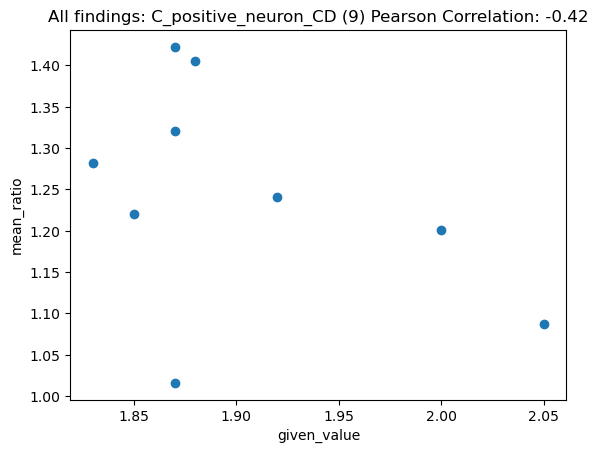

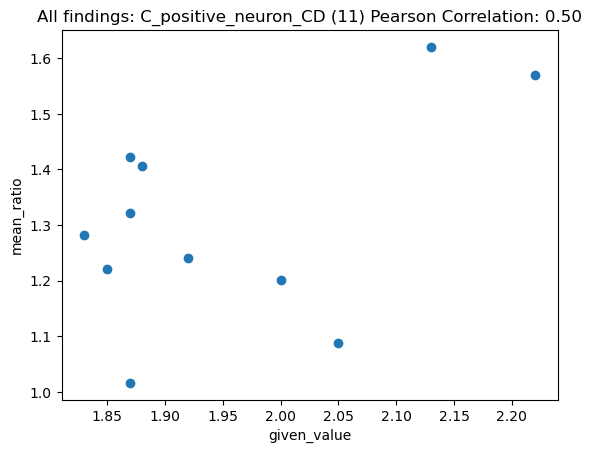

In [14]:
# investigate dna count and rna count values of chengyu data 
n_bcs = 70
# chengyu_positive = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_neuron_CD']
chengyu_positive_raw = merged_replicates_df[merged_replicates_df['label'] == 'C_positive_neuron_CD']
print(chengyu_positive_raw.shape[0])
# filter the merged_tsv
chengyu_positive_raw

# filter for being observed in all 3 barcodes
chengyu_positive_3_reps = chengyu_positive_raw[chengyu_positive_raw['replicates'] == 3]
# # filter for at least 20 barcodes
chengyu_positive_3_reps_mean_bcs = chengyu_positive_3_reps[chengyu_positive_3_reps['mean_n_obs_bc'] >= n_bcs]

chengyu_positive_3_reps_mean_bcs['given_ratio'] = chengyu_positive_3_reps_mean_bcs['name'].apply(get_ratio_chengyu)

# filter outliers out
filtered_chengyu = chengyu_positive_3_reps_mean_bcs[chengyu_positive_3_reps_mean_bcs['mean_ratio'] < 1.45]

plot_correlation(filtered_chengyu, 'given_ratio', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_neuron_CD')
plot_correlation(chengyu_positive_3_reps_mean_bcs, 'given_ratio', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_neuron_CD')


# # filter for RNA min 10
# chengyu_positive_3_reps_mean_bcs_rna_filter = chengyu_positive_3_reps_mean_bcs[chengyu_positive_3_reps_mean_bcs['mean_rna_counts'] >= 100]

# plot_correlation(chengyu_positive_3_reps_mean_bcs_rna_filter, 'given_ratio', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_neuron_CD')


# # plot range of 75% of the data
# # dna_counts
# plt.boxplot(chengyu_positive['dna_counts'])
# plt.title('DNA counts of Chengyu positive neuron CD')
# plt.show()
# plt.boxplot(chengyu_positive['rna_counts'])
# plt.title('RNA counts of Chengyu positive neuron CD')
# plt.show()


# # histplot of dna counts and rna counts
# plt.hist(chengyu_positive['dna_counts'], bins=100)
# plt.title('DNA counts of Chengyu positive neuron CD')
# plt.show()
# plt.title('RNA counts of Chengyu positive neuron CD')
# plt.hist(chengyu_positive['rna_counts'], bins=100)
# plt.show()





In [ ]:
print("All controls in bc MPRAlm: ", controls.shape[0])
controls['label'].value_counts()
# label
# GC_Selvarajan            150
# GC_Kircher               140
# GC_Mendelian_variants     41
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

# solved mendelian variants problem
# label
# GC_Selvarajan            150
# GC_Mendelian_variants    147
# GC_Kircher               140
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

All controls in bc MPRAlm:  514


label
GC_Selvarajan            150
GC_Mendelian_variants    147
GC_Kircher               140
C_positive_heart_CAD      39
GC_Atrial_fib             20
GC_Mohlke                 13
GC_Liang                   5
Name: count, dtype: int64

In [22]:
merged_tsv_aggregated = merged_tsv.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )

In [23]:
merged_tsv_aggregated

replicate  \
                                                                 count   
condition name                                                           
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...         3   
...                                                                ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...         3   
          no_BC                                                      3   

                                                             dna_counts  \
                                                                    sum   
condition name                                                            
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       1069   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       1140   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        638   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        922   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...        595   
...                                                                 ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        631   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        197   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        216   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        946   
          no_BC                                                40574076   

                                                                            \
                                                                      mean   
condition name                                                               
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...  3.563333e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...  3.800000e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  2.126667e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  3.073333e+02   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...  1.983333e+02   
...                                                                    ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  2.103333e+02   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  6.566667e+01   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  7.200000e+01   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...  3.153333e+02   
          no_BC                                               1.352469e+07   

                                                             rna_counts  \
                                                                    sum   
condition name                                                            
NGN2      C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       2587   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V...       5188   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       1632   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       2260   
          C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_...       1412   
...                                                                 ...   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...       2799   
          cardiac_neuro_cava_random:ZNF462|ENSG0000014814...        646   
          cardiac_neuro_cava_random:ZNF462|ENSG00000148

##### Investigate with 10 barcodes

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_positive_heart_MK['given_value'] = C_positive_heart_MK['name'].apply(get_ratio_with_underscore)


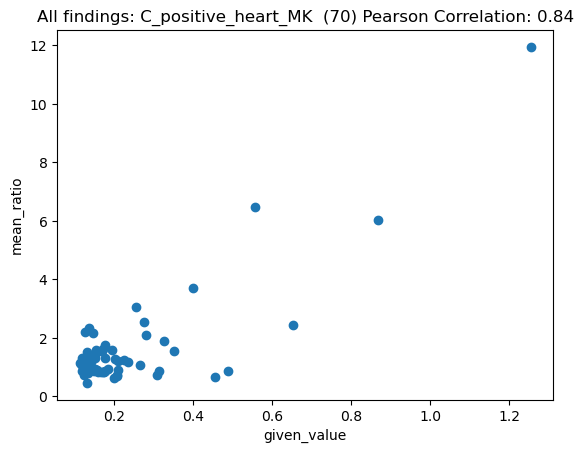

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_negative_heart_MK['given_value'] = C_negative_heart_MK['name'].apply(get_ratio_with_underscore)


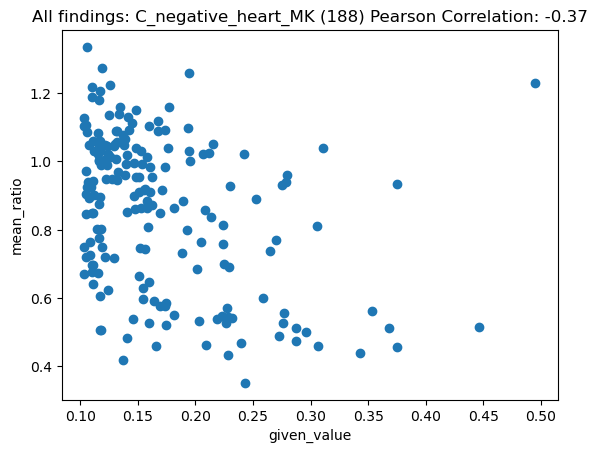

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_negative_neuron_MK['given_value'] = C_negative_neuron_MK['name'].apply(get_ratio_with_underscore)


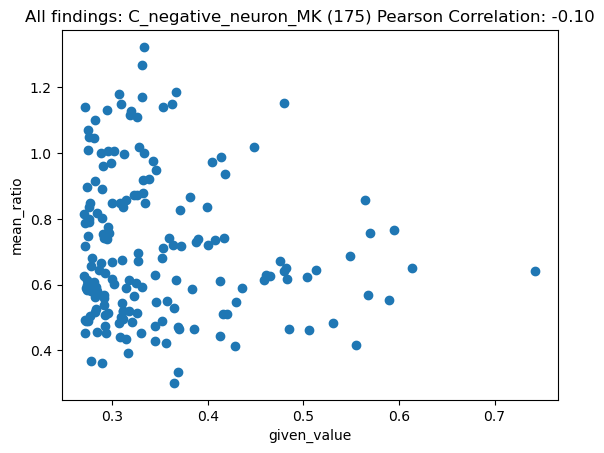

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_negative_neuron_NP['given_value'] = C_negative_neuron_NP['name'].apply(get_ratio_with_underscore)


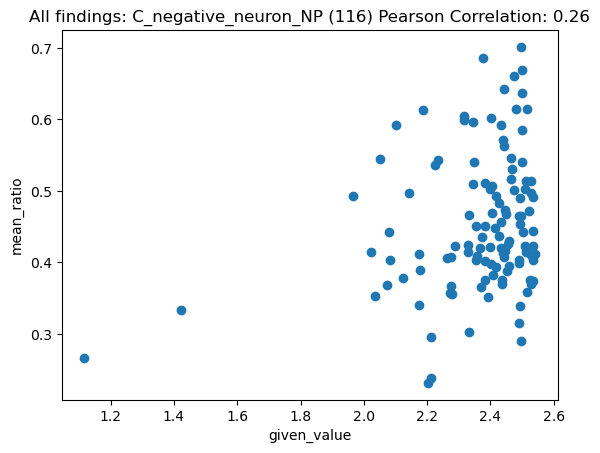

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_positive_neuron_MK['given_value'] = C_positive_neuron_MK['name'].apply(get_ratio_with_underscore)


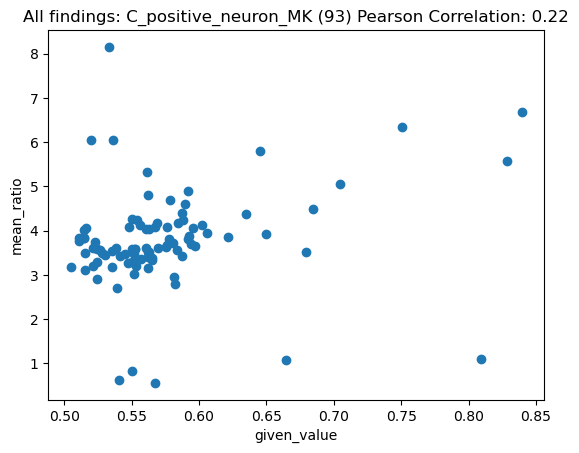

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1445569/2197616266.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_positive_neuron_NP['given_value'] = C_positive_neuron_NP['name'].apply(get_ratio_with_underscore)


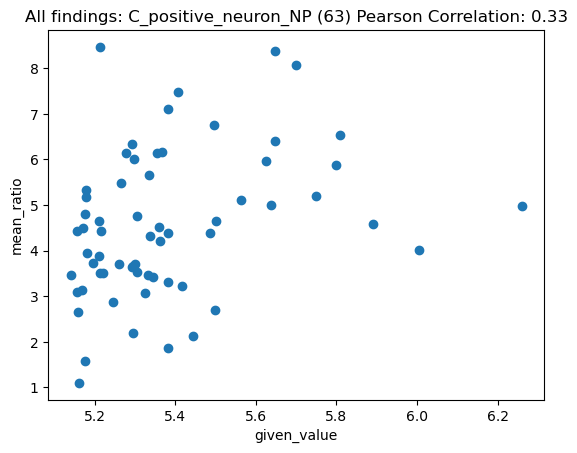

In [24]:
# C_positive_heart_MK
C_positive_heart_MK = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_heart_MK']
C_positive_heart_MK['given_value'] = C_positive_heart_MK['name'].apply(get_ratio_with_underscore)
plot_correlation(C_positive_heart_MK, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_heart_MK ')


# C_negative_heart_MK
C_negative_heart_MK = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_negative_heart_MK']
C_negative_heart_MK['given_value'] = C_negative_heart_MK['name'].apply(get_ratio_with_underscore)
plot_correlation(C_negative_heart_MK, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_negative_heart_MK')


# C_negative_neuron_MK
C_negative_neuron_MK = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_negative_neuron_MK']
C_negative_neuron_MK['given_value'] = C_negative_neuron_MK['name'].apply(get_ratio_with_underscore)
plot_correlation(C_negative_neuron_MK, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_negative_neuron_MK')


# C_negative_neuron_NP
C_negative_neuron_NP = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_negative_neuron_NP']
C_negative_neuron_NP['given_value'] = C_negative_neuron_NP['name'].apply(get_ratio_with_underscore)
plot_correlation(C_negative_neuron_NP, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_negative_neuron_NP')

# C_positive_neuron_MK
C_positive_neuron_MK = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_neuron_MK']
C_positive_neuron_MK['given_value'] = C_positive_neuron_MK['name'].apply(get_ratio_with_underscore)
plot_correlation(C_positive_neuron_MK, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_neuron_MK')

# C_positive_neuron_NP
C_positive_neuron_NP = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_neuron_NP']
C_positive_neuron_NP['given_value'] = C_positive_neuron_NP['name'].apply(get_ratio_with_underscore)
plot_correlation(C_positive_neuron_NP, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', 'All findings: C_positive_neuron_NP')




/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-187/ipykernel_3275779/3779636317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_neuron_chengyu['given_mean_ratio'] = positive_neuron_chengyu['name'].apply(get_ratio_chengyu)
/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-187/ipykernel_3275779/3779636317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_neuron_chengyu['str_given_mean_ratio'] = positive_neuron_chengyu['name'].apply(get_ratio_string_chengyu)


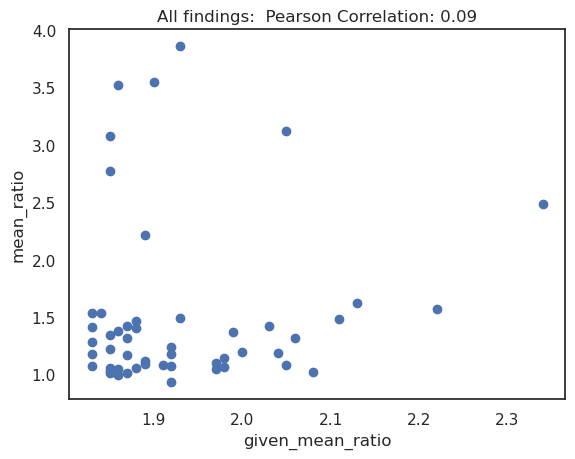

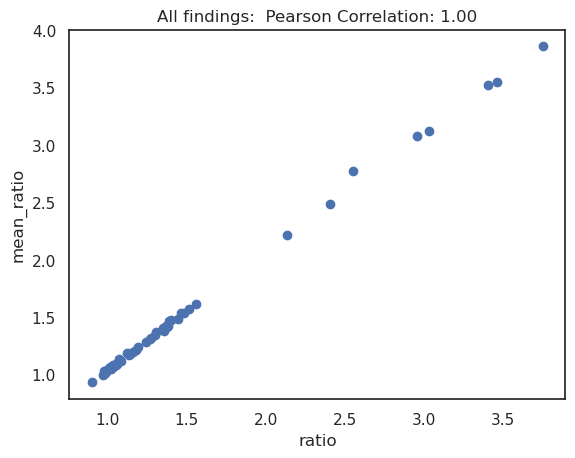

In [105]:
# correlate positive neuron cd with your data
positive_neuron_chengyu = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_neuron_CD']
positive_neuron_chengyu.shape[0] #51
positive_neuron_chengyu['given_mean_ratio'] = positive_neuron_chengyu['name'].apply(get_ratio_chengyu)
positive_neuron_chengyu['str_given_mean_ratio'] = positive_neuron_chengyu['name'].apply(get_ratio_string_chengyu)
# positive_neuron_chengyu['name'].to_list()
positive_neuron_chengyu
# receive mean ration: 

plot_correlation(positive_neuron_chengyu, 'given_mean_ratio', 'mean_ratio', 'given_mean_ratio', 'mean_ratio', 'All findings: ')
# # visualize correlation between given_mean_ratio and mean_ratio
# # Calculate Pearson correlation coefficient
# pearson_corr = positive_neuron_chengyu['given_mean_ratio'].corr(positive_neuron_chengyu['mean_ratio'])

# # # Plot correlation using Seaborn's jointplot
# # sns.jointplot(x='given_mean_ratio', y='mean_ratio', data=positive_neuron_chengyu, kind='scatter')
# # plt.suptitle(f'Pearson Correlation: {pearson_corr:.2f}', y=1.02)
# # plt.show()


# # Plot correlation using Matplotlib's scatter plot
# plt.scatter(positive_neuron_chengyu['given_mean_ratio'], positive_neuron_chengyu['mean_ratio'])
# plt.xlabel('given_mean_ratio')
# plt.ylabel('mean_ratio')
# plt.title(f'Pearson Correlation: {pearson_corr:.2f}')
# plt.show()

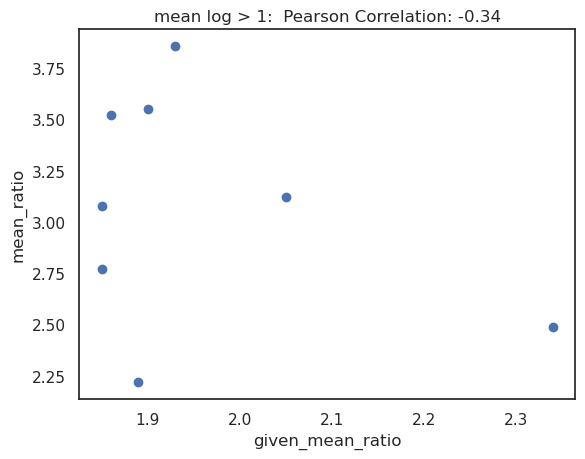

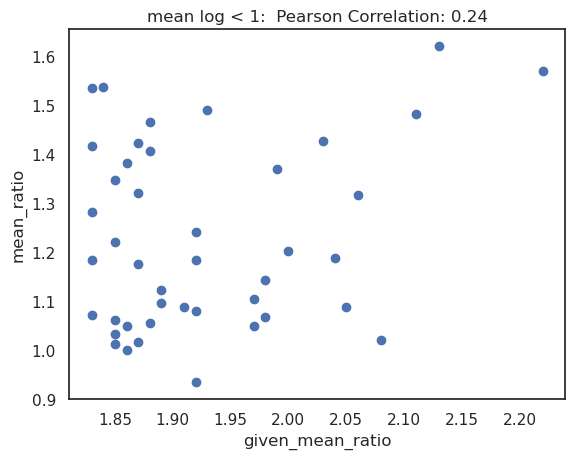

In [100]:
# split into groups and correlate again
high_log2_chengyu = positive_neuron_chengyu[positive_neuron_chengyu['mean_log2'] > 1]
# receive mean ration: 

plot_correlation(high_log2_chengyu, 'given_mean_ratio', 'mean_ratio', 'given_mean_ratio', 'mean_ratio', 'mean log > 1: ')


# # visualize correlation between given_mean_ratio and mean_ratio
# # Calculate Pearson correlation coefficient
# pearson_corr = high_log2_chengyu['given_mean_ratio'].corr(high_log2_chengyu['mean_ratio'])

# # # Plot correlation using Seaborn's jointplot
# # sns.jointplot(x='given_mean_ratio', y='mean_ratio', data=high_log2_chengyu, kind='scatter')
# # plt.suptitle(f'Pearson Correlation: {pearson_corr:.2f}', y=1.02)
# # plt.show()


# # Plot correlation using Matplotlib's scatter plot
# plt.scatter(high_log2_chengyu['given_mean_ratio'], high_log2_chengyu['mean_ratio'])
# plt.xlabel('given_mean_ratio')
# plt.ylabel('mean_ratio')
# plt.title(f'Pearson Correlation: {pearson_corr:.2f}')
# plt.show()




low_log2_chengyu = positive_neuron_chengyu[positive_neuron_chengyu['mean_log2'] < 1]
# receive mean ration: 
plot_correlation(low_log2_chengyu, 'given_mean_ratio', 'mean_ratio', 'given_mean_ratio', 'mean_ratio', 'mean log < 1: ')

# # visualize correlation between given_mean_ratio and mean_ratio
# # Calculate Pearson correlation coefficient
# pearson_corr = low_log2_chengyu['given_mean_ratio'].corr(low_log2_chengyu['mean_ratio'])

# # # Plot correlation using Seaborn's jointplot
# # sns.jointplot(x='given_mean_ratio', y='mean_ratio', data=low_log2_chengyu, kind='scatter')
# # plt.suptitle(f'Pearson Correlation: {pearson_corr:.2f}', y=1.02)
# # plt.show()


# # Plot correlation using Matplotlib's scatter plot
# plt.scatter(low_log2_chengyu['given_mean_ratio'], low_log2_chengyu['mean_ratio'])
# plt.xlabel('given_mean_ratio')
# plt.ylabel('mean_ratio')
# plt.title(f'Pearson Correlation: {pearson_corr:.2f}')
# plt.show()

##### Check replicates for correlation individually

In [86]:
merged_tsv.head()

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,label
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.039527,0.055928,106,C_SLEA
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.320821,1.214635,99,C_SLEA
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.132836,0.179939,68,C_SLEA
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.216045,0.282196,89,C_SLEA
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.014363,0.020575,54,C_SLEA


In [84]:
merged_tsv['label'] = merged_tsv['name'].apply(hf.get_label)

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-187/ipykernel_3275779/2281864274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_neuron_chengyu_reps['given_mean_ratio'] = positive_neuron_chengyu_reps['name'].apply(get_ratio_chengyu)


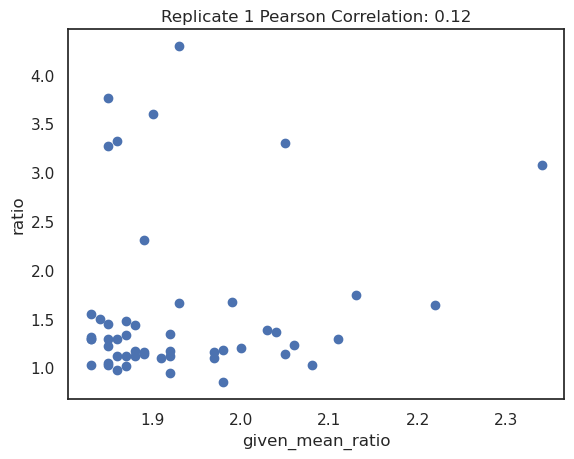

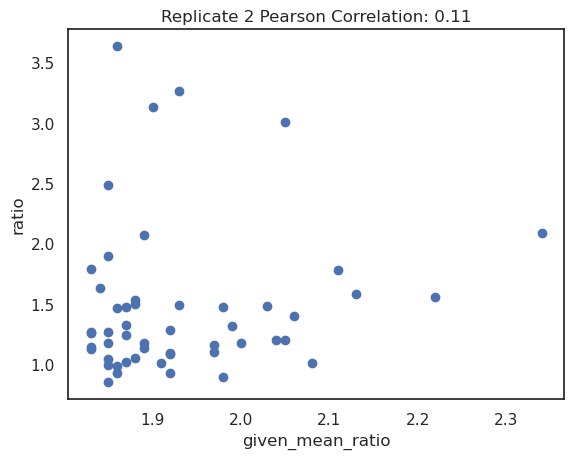

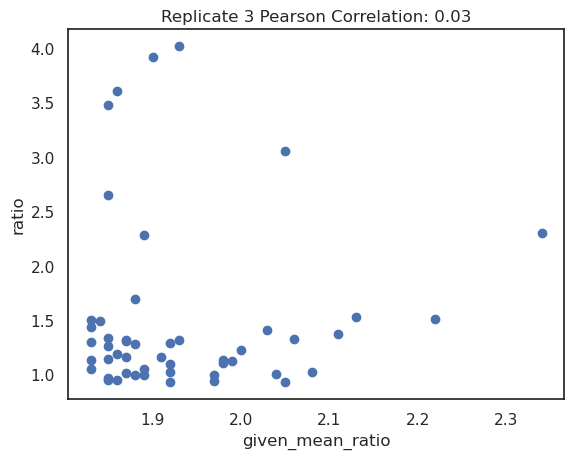

152


In [96]:
positive_neuron_chengyu_reps = merged_tsv[merged_tsv['label'] == 'C_positive_neuron_CD']
positive_neuron_chengyu_reps['given_mean_ratio'] = positive_neuron_chengyu_reps['name'].apply(get_ratio_chengyu)

positive_neuron_chengyu_first = positive_neuron_chengyu_reps[positive_neuron_chengyu_reps['replicate'] == 1]
plot_correlation(positive_neuron_chengyu_first, 'given_mean_ratio', 'ratio', 'given_mean_ratio', 'ratio', 'Replicate 1')

positive_neuron_chengyu_second = positive_neuron_chengyu_reps[positive_neuron_chengyu_reps['replicate'] == 2]
plot_correlation(positive_neuron_chengyu_second, 'given_mean_ratio', 'ratio', 'given_mean_ratio', 'ratio', 'Replicate 2')

positive_neuron_chengyu_third = positive_neuron_chengyu_reps[positive_neuron_chengyu_reps['replicate'] == 3]
plot_correlation(positive_neuron_chengyu_third, 'given_mean_ratio', 'ratio', 'given_mean_ratio', 'ratio', 'Replicate 3')

print(positive_neuron_chengyu_reps.shape[0]) #51
# positive_neuron_chengyu_reps['str_given_mean_ratio'] = positive_neuron_chengyu_reps['name'].apply(get_ratio_string_chengyu)
# # positive_neuron_chengyu_reps['name'].to_list()
# positive_neuron_chengyu_reps
# # receive mean ration: 

# # visualize correlation between given_mean_ratio and mean_ratio
# # Calculate Pearson correlation coefficient
# pearson_corr = positive_neuron_chengyu_reps['given_mean_ratio'].corr(positive_neuron_chengyu_reps['ratio'])

# # # Plot correlation using Seaborn's jointplot
# # sns.jointplot(x='given_mean_ratio', y='mean_ratio', data=positive_neuron_chengyu_reps, kind='scatter')
# # plt.suptitle(f'Pearson Correlation: {pearson_corr:.2f}', y=1.02)
# # plt.show()


# # Plot correlation using Matplotlib's scatter plot
# plt.scatter(positive_neuron_chengyu_reps['given_mean_ratio'], positive_neuron_chengyu_reps['mean_ratio'])
# plt.xlabel('given_mean_ratio')
# plt.ylabel('mean_ratio')
# plt.title(f'Pearson Correlation: {pearson_corr:.2f}')
# plt.show()

In [ ]:
['GC_Vista', 'GC_DNase_positive_shuffeled', 'GC_Mendelian_variants', 'C_SLEA']

In [12]:
def is_group(header, group):
    """Only get rows of a certain group"""
    return header.split(":")[0].lower() == group.lower()


def is_vista(header):
    return is_group(header, 'GC_Vista')


def is_dnase_pos_shuffled(header):
    return is_group(header, 'GC_DNase_positive_shuffeled')


def is_mendelian_variant(header):
    return is_group(header, 'GC_Mendelian_variants')


def is_slea_control(header):
    return header.split(":")[0].lower() == 'C_SLEA'.lower()

In [13]:
dnase_pos_shuffled = allreps_minthreshold_df[allreps_minthreshold_df['name'].apply(is_dnase_pos_shuffled)]
print(f'GC_DNase_positive_shuffeled', dnase_pos_shuffled.shape[0]) # 18.04.2024 51
dnase_pos_shuffled_3_reps = dnase_pos_shuffled[dnase_pos_shuffled['replicates'] == 3]
print(f'GC_DNase_positive_shuffeled_all_replicates: ', dnase_pos_shuffled_3_reps.shape[0]) # 18.04.2024 51
dnase_pos_shuffled_3_reps.head()

GC_DNase_positive_shuffeled 51
GC_DNase_positive_shuffeled_all_replicates:  51


,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,label
1907,NGN2,GC_DNase_positive_shuffeled:chr10:103815920-10...,3,548,1072,6.744873,5.697950,0.844782,-0.243348,182.666667,357.333333,0.157530,0.134689,0.882427,-0.196106,GC_DNase_positive_shuffeled
1908,NGN2,GC_DNase_positive_shuffeled:chr10:42369184-423...,3,546,1198,6.720257,6.367672,0.947534,-0.077750,182.000000,399.333333,0.114206,0.108278,0.980448,-0.028596,GC_DNase_positive_shuffeled
1909,NGN2,GC_DNase_positive_shuffeled:chr10:42390853-423...,3,1335,3370,16.431397,17.912400,1.090132,0.124503,445.000000,1123.333333,0.149761,0.162993,1.125061,0.169960,GC_DNase_positive_shuffeled
1910,NGN2,GC_DNase_positive_shuffeled:chr10:42393728-423...,3,831,2102,10.228083,11.172660,1.092351,0.127437,277.000000,700.666667,0.120409,0.131650,1.136187,0.178738,GC_DNase_positive_shuffeled
1911,NGN2,GC_DNase_positive_shuffeled:chr10:42527153-425...,3,671,692,8.258777,3.678155,0.445363,-1.166946,223.666667,230.666667,0.084286,0.037439,0.466354,-1.109683,GC_DNase_positive_shuffeled


In [162]:
allreps_minthreshold_df['label'].nunique()

29

In [161]:
allreps_minthreshold_df['label'].value_counts()

label
cardiac_neuro_cava_random            63737
MK                                    1998
C_positive_heart_AB                    573
GC_Selvarajan                          320
GC_Vista                               222
GC_Mendelian_variants                  194
C_negative_heart_MK                    188
GC_Cort_Chengyu                        185
C_negative_neuron_MK                   175
C_SLEA                                 162
GC_Kircher                             155
C_negative_neuron_NP                   116
C_positive_neuron_MK                    93
C_positive_heart_CAD                    86
C_positive_heart_MK                     70
GC_GABA_Chengyu                         69
C_positive_neuron_NP                    63
GC_DNase_positive_shuffeled             51
C_positive_neuron_CD                    51
GC_Atrial_fib                           44
GC_DNase_positive                       37
GC_Glut_Chengyu                         31
GC_Mohlke                               30
GC_DN

In [14]:
slea_controls = allreps_minthreshold_df[allreps_minthreshold_df['name'].apply(is_slea_control)]
print(slea_controls.shape[0]) # 18.04.2024: 162
# are all these sequences in 3 replicates? - In design: 200 sequences -> here 160 are in 3 replicates
slea_controls['replicates'].value_counts()
# replicates: 18.04.2024
# 3    160
# 2      1
# 1      1

slea_controls_3_reps = slea_controls[slea_controls['replicates'] == 3]
slea_controls_3_reps
# how many positive and how many negative?
slea_pos = slea_controls_3_reps[slea_controls_3_reps['mean_log2'] > 0]
print('SLEA positive: ', slea_pos.shape[0])
slea_neg = slea_controls_3_reps[slea_controls_3_reps['mean_log2'] < 0]
print('SLEA negative: ', slea_neg.shape[0])

slea_controls.head()

162
SLEA positive:  114
SLEA negative:  46


,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,356.333333,862.333333,0.121140,0.126572,1.080802,0.111316,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,380.000000,1729.333333,0.137726,0.270879,2.040802,1.022238,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,212.666667,544.000000,0.116224,0.128225,1.140693,0.189335,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,307.333333,753.333333,0.124520,0.132123,1.099769,0.132576,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,198.333333,470.666667,0.133440,0.136954,1.060619,0.084120,C_SLEA


In [15]:
vista_enhancer = allreps_minthreshold_df[allreps_minthreshold_df['name'].apply(is_vista)]
print(f'GC_DNase_positive_shuffeled', vista_enhancer.shape[0]) # 18.04.2024 51
vista_enhancer_3_reps = vista_enhancer[vista_enhancer['replicates'] == 3]
print(f'GC_DNase_positive_shuffeled_all_replicates: ', vista_enhancer_3_reps.shape[0]) # 18.04.2024 51
vista_enhancer_3_reps.head()

GC_DNase_positive_shuffeled 222
GC_DNase_positive_shuffeled_all_replicates:  216


,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,label
2775,NGN2,GC_Vista:;eye;fb;fm;hb;mb_;hs1523_vistaElement...,3,619,1563,7.618753,8.307739,1.090433,0.124901,206.333333,521.000000,0.104112,0.114188,1.135310,0.180762,GC_Vista
2777,NGN2,GC_Vista:;fb;hb;mb;nt_;hs1188_vistaElementCont...,3,733,1802,9.021883,9.578084,1.061650,0.086309,244.333333,600.666667,0.121529,0.128943,1.096462,0.131576,GC_Vista
2778,NGN2,GC_Vista:;fb;lb_;hs200_vistaElementControl|chr...,3,963,2451,11.852761,13.027683,1.099126,0.136357,321.000000,817.000000,0.143641,0.158399,1.143457,0.188461,GC_Vista
2779,NGN2,GC_Vista:;fb;lb_;hs200_vistaElementControl|chr...,3,1062,2958,13.071269,15.722516,1.202830,0.266433,354.000000,986.000000,0.138490,0.166828,1.244596,0.315395,GC_Vista
2780,NGN2,GC_Vista:;fb;mb_;hs271_vistaElementControl|chr...,3,967,2648,11.901993,14.074788,1.182557,0.241910,322.333333,882.666667,0.146908,0.173762,1.223646,0.288843,GC_Vista


In [141]:
def plot_histogram(df, group, bins=30):
    """Plot histogram of given group"""
    group_df = df[df['label'] == group]
    group_df_3_replicates = group_df[group_df['replicates'] == 3]
    # add title
    sns.histplot(group_df_3_replicates['mean_log2'], bins=bins, color='blue', alpha=0.75)
    
    # add dashed line at zero
    plt.axvline(x=0, color='red', linestyle='--')
    
    plt.title(f'{group} ({group_df_3_replicates.shape[0]})')
    plt.xlim(-2,3.5)
    plt.show()
    
    
def plot_kde(df, group):
    """Plot histogram of given group"""
    group_df = df[df['label'] == group]
    group_df_3_replicates = group_df[group_df['replicates'] == 3]
    # add title
    sns.displot(group_df_3_replicates, x= "mean_log2", kind="kde")
    plt.title(f'{group} ({group_df_3_replicates.shape[0]})')
    plt.xlim(-2,3.5)
    plt.show()
    

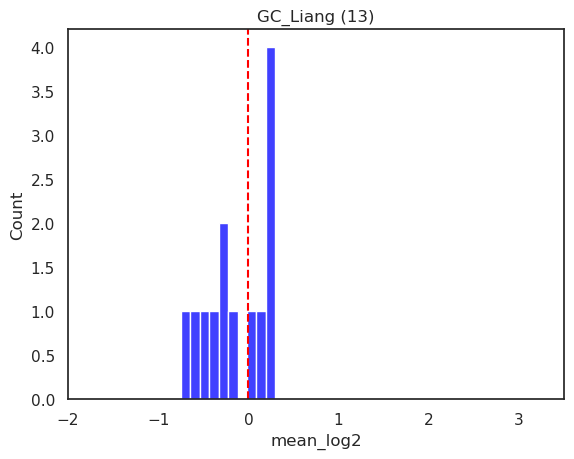

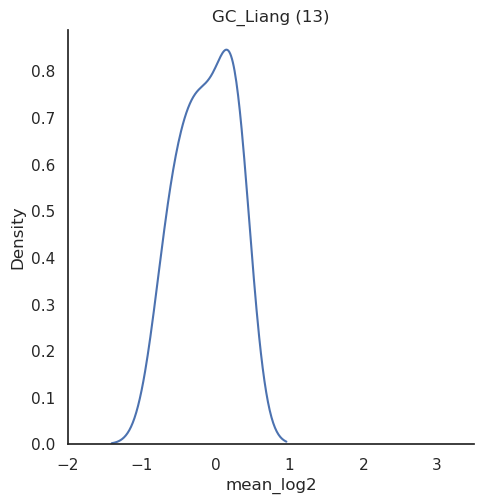

In [169]:
pos_neg_neuron = ['GC_Mohlke', 'GC_Kircher', 'C_positive_neuron_CD', 'C_positive_neuron_MK', 'C_positive_neuron_NP', 'C_negative_neuron_MK', 'C_negative_neuron_NP' ]
pos_neg_neuron = ['GC_Liang' ] #'GC_Kircher', 'C_positive_neuron_CD', 'C_positive_neuron_MK', 'C_positive_neuron_NP', 'C_negative_neuron_MK', 'C_negative_neuron_NP' ]
for group in pos_neg_neuron:
    plot_histogram(allreps_minthreshold_df, group, bins=10)
    plot_kde(allreps_minthreshold_df, group)


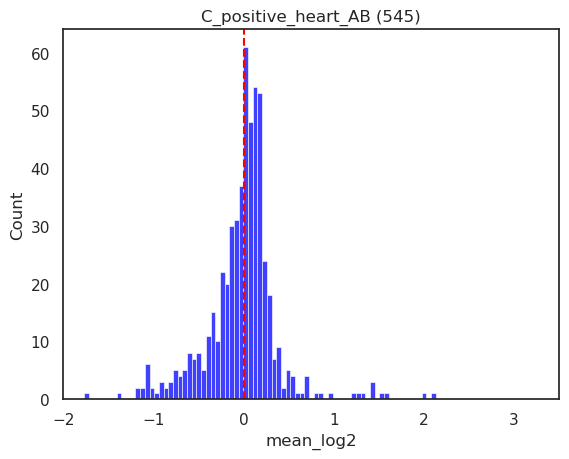

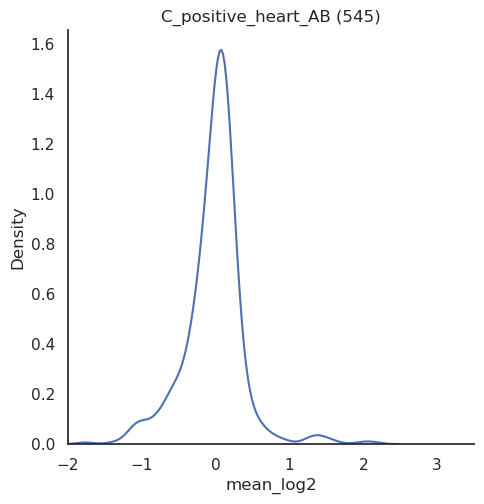

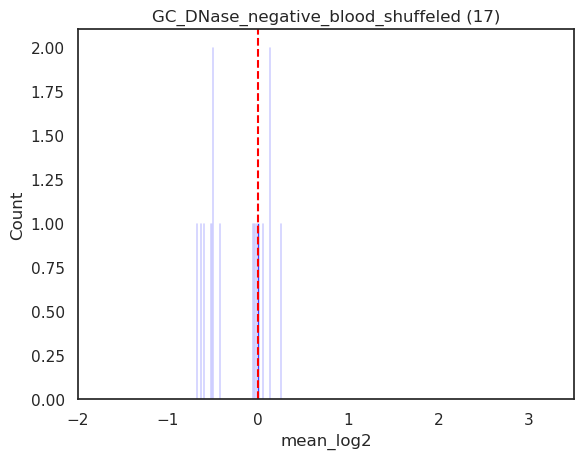

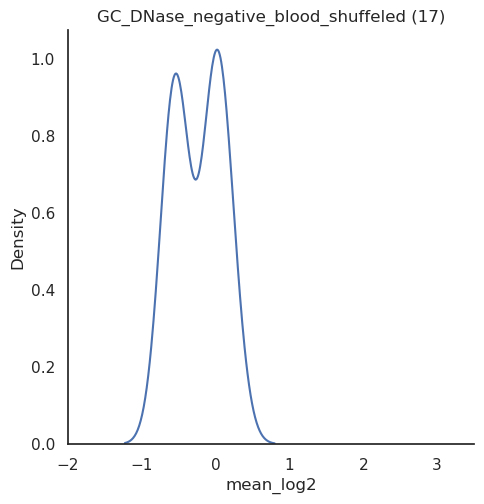

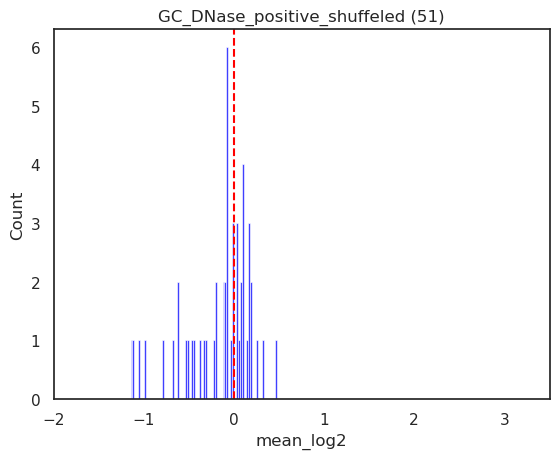

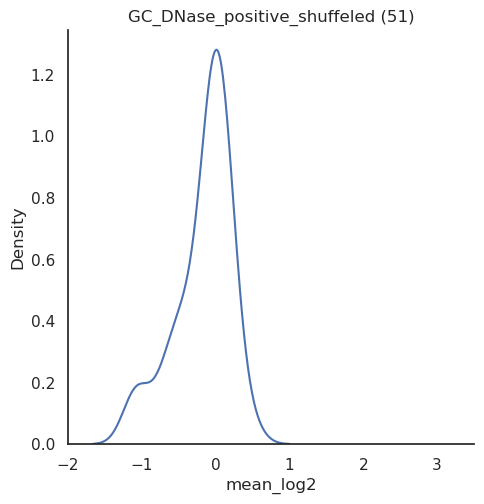

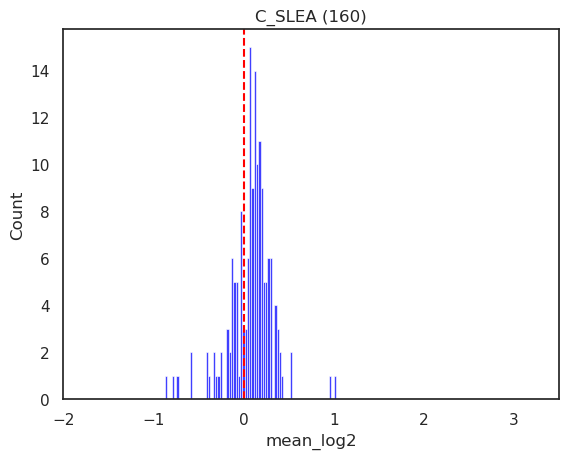

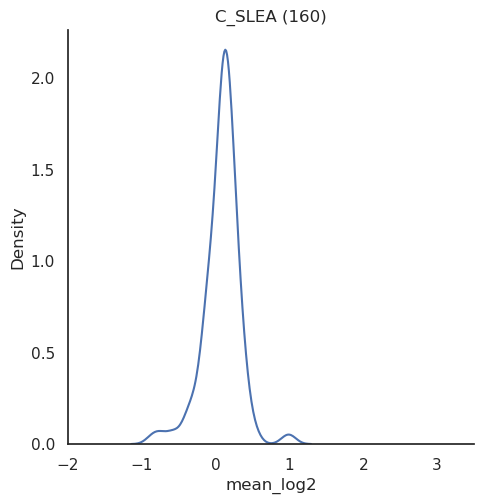

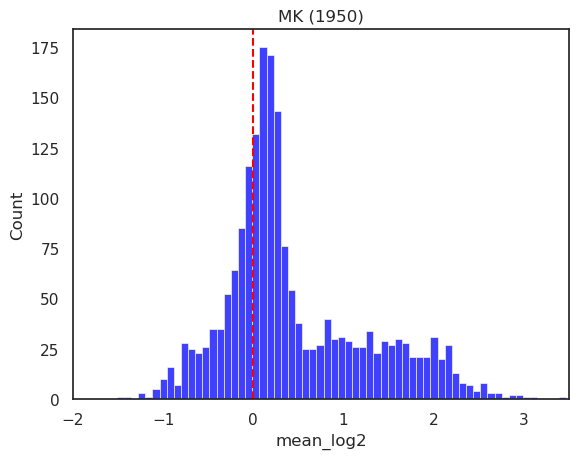

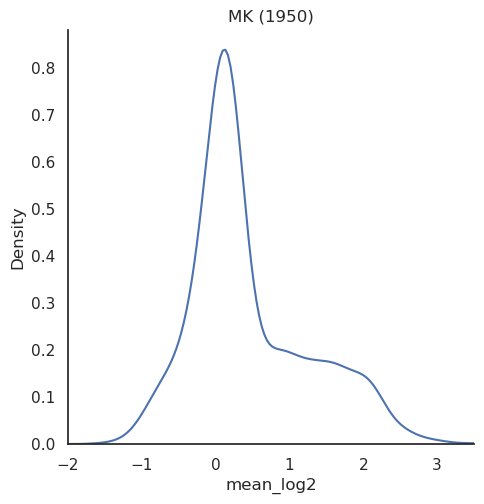

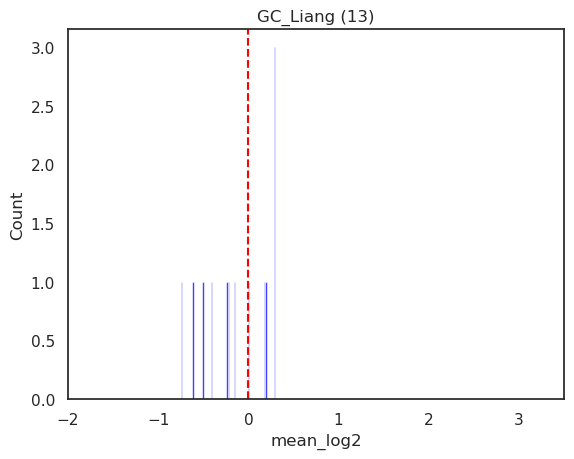

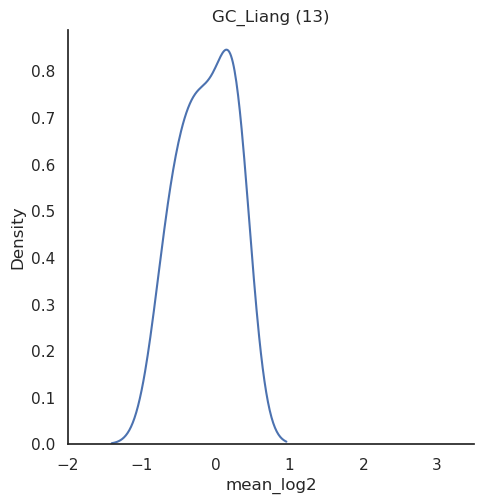

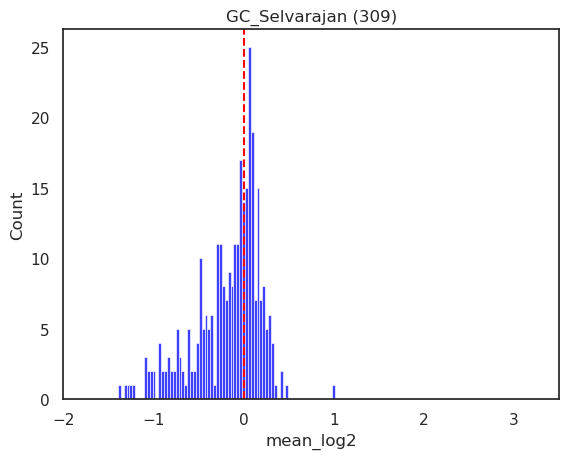

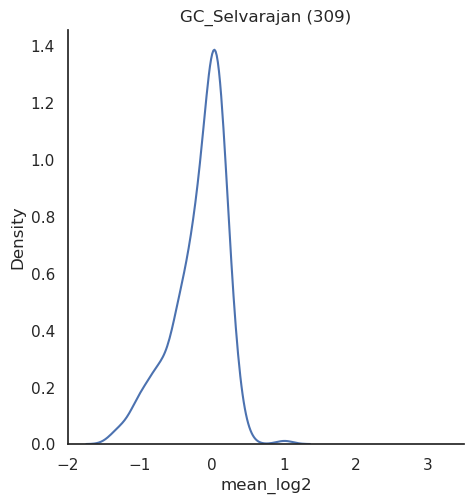

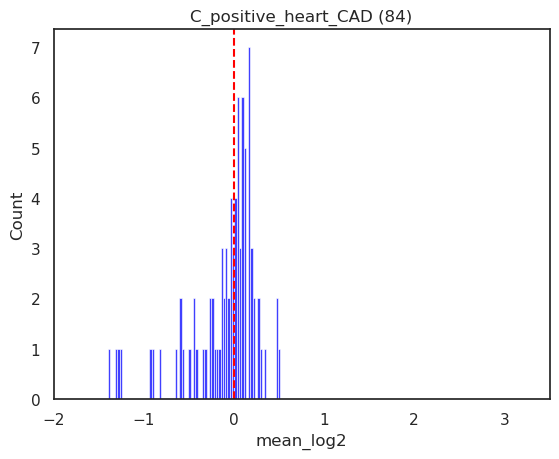

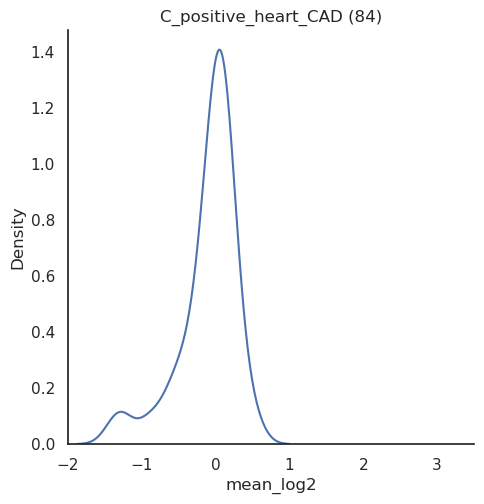

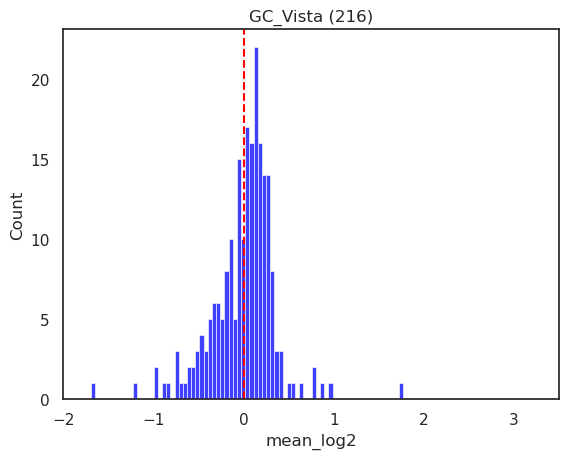

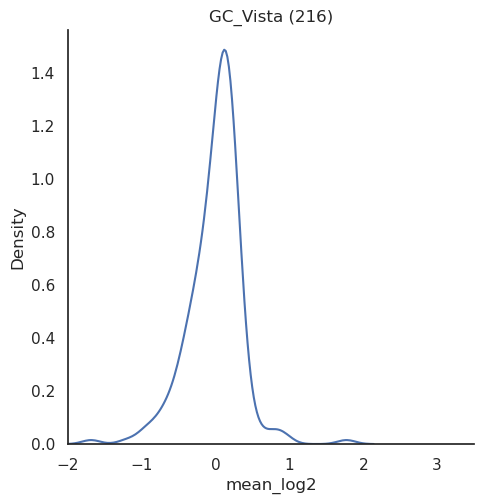

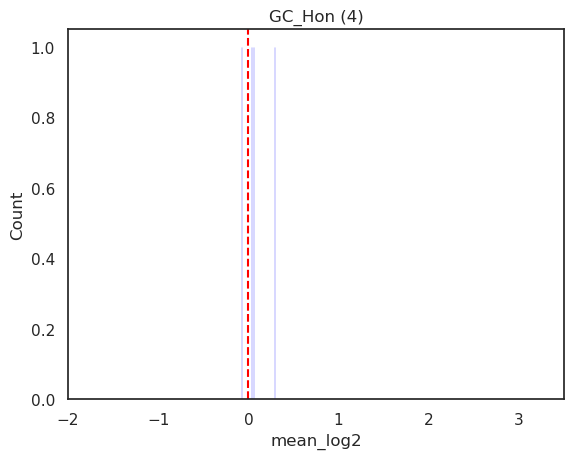

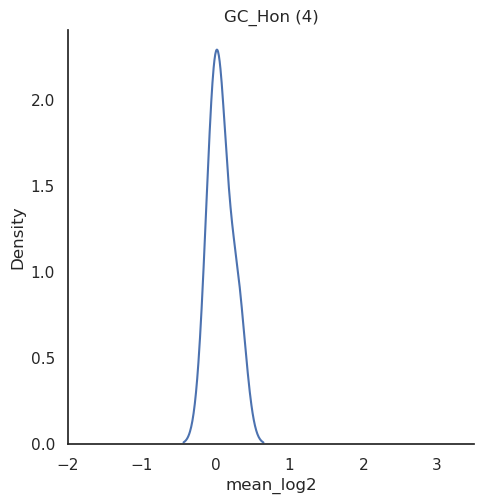

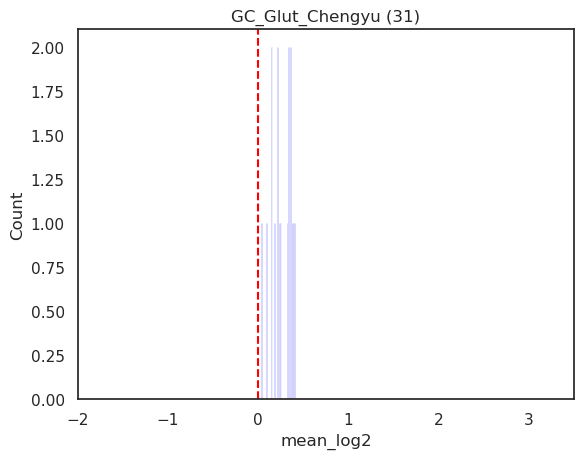

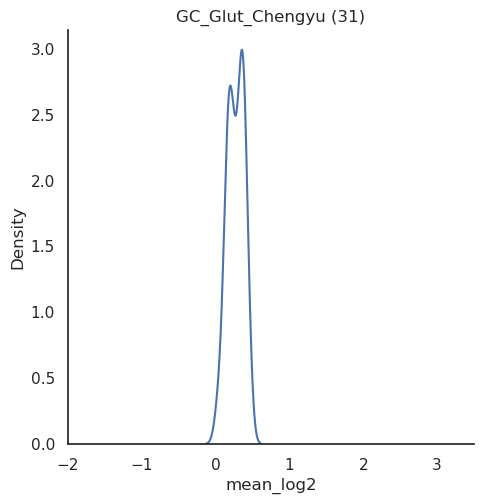

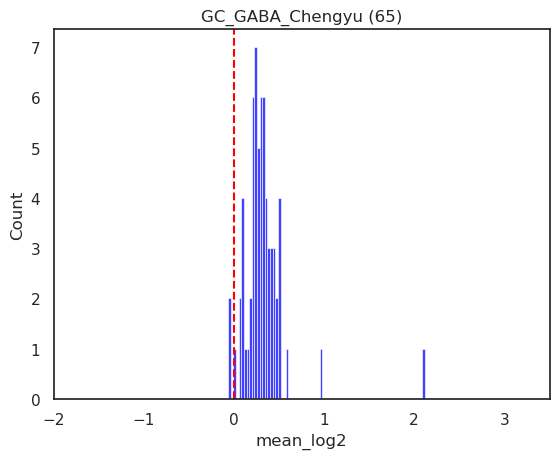

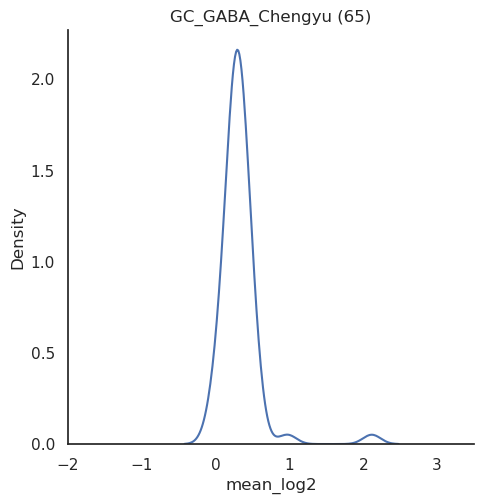

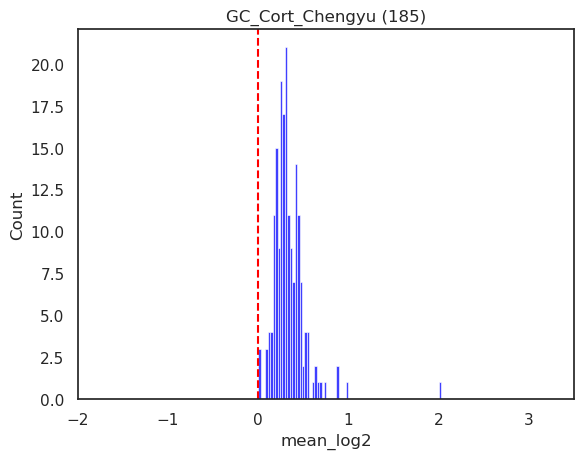

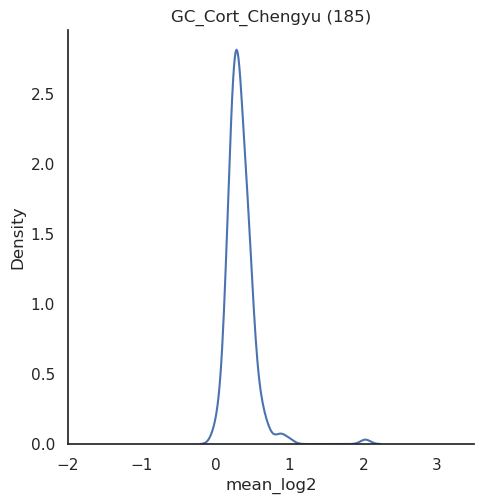

In [160]:
pos_neg_neuron = ['C_positive_heart_AB', 'GC_DNase_negative_blood_shuffeled', 'GC_DNase_positive_shuffeled', 'C_SLEA', 'MK', 'GC_Liang', 'GC_Selvarajan', 'C_positive_heart_CAD', 'GC_Vista', 'GC_Hon', 'GC_Glut_Chengyu', 'GC_GABA_Chengyu', 'GC_Cort_Chengyu']
for group in pos_neg_neuron:
    plot_histogram(allreps_minthreshold_df, group, bins=75)
    plot_kde(allreps_minthreshold_df, group)

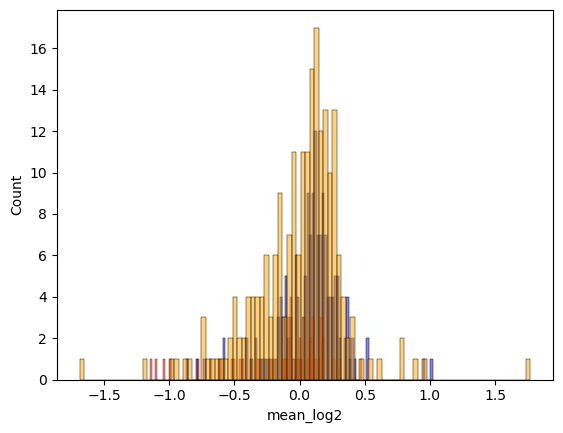

<Figure size 640x480 with 0 Axes>

In [16]:
# plot the log2FC distribution of these elements
import matplotlib.pyplot as plt
import seaborn as sns
plt.clf()
# add title to the plot: "C_SLEA controls 100 positive and 100 negative"

sns.histplot(slea_controls_3_reps['mean_log2'], bins=100, color="blue", alpha=0.5)
sns.histplot(dnase_pos_shuffled_3_reps['mean_log2'], bins=100, color="red", alpha=0.5)
sns.histplot(vista_enhancer_3_reps['mean_log2'], bins=100, color="orange", alpha=0.5)

plt.show()

# clear plot
plt.clf()


In [17]:
slea_controls_3_reps.head()

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,356.333333,862.333333,0.121140,0.126572,1.080802,0.111316,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,380.000000,1729.333333,0.137726,0.270879,2.040802,1.022238,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,212.666667,544.000000,0.116224,0.128225,1.140693,0.189335,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,307.333333,753.333333,0.124520,0.132123,1.099769,0.132576,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,198.333333,470.666667,0.133440,0.136954,1.060619,0.084120,C_SLEA


In [29]:
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
# add normal distribution values in mean_log2 and label=Normal distribution mean:0 sd: 0.5
norm_mean=0
norm_sd=1
norm_value_number = 1000
x = np.linspace(-2, 2, norm_value_number)
normal_distribution_values = stats.norm.pdf(x, norm_mean, norm_sd)
label = [f'Normal distribution (mean:{norm_mean}, sd: {norm_sd})']*norm_value_number
normal_distribution = pd.DataFrame({'name': x, 'mean_log2': normal_distribution_values, 'label': label})
normal_distribution

,name,mean_log2,label
0,-2.000000,0.053991,"Normal distribution (mean:0, sd: 1)"
1,-1.995996,0.054425,"Normal distribution (mean:0, sd: 1)"
2,-1.991992,0.054861,"Normal distribution (mean:0, sd: 1)"
3,-1.987988,0.055300,"Normal distribution (mean:0, sd: 1)"
4,-1.983984,0.055741,"Normal distribution (mean:0, sd: 1)"
...,...,...,...
995,1.983984,0.055741,"Normal distribution (mean:0, sd: 1)"
996,1.987988,0.055300,"Normal distribution (mean:0, sd: 1)"
997,1.991992,0.054861,"Normal distribution (mean:0, sd: 1)"
998,1.995996,0.054425,"Normal distribution (mean:0, sd: 1)"


(160, 16)

(51, 16)

(216, 16)

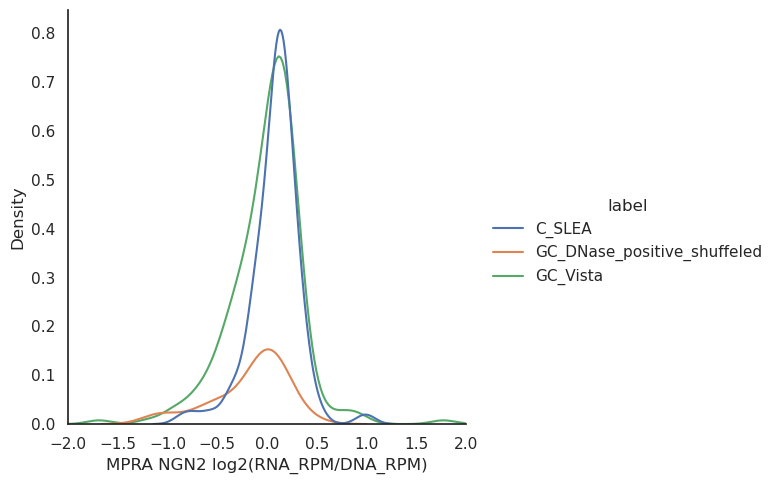

In [42]:
sns.set_theme(style='white')
display(slea_controls_3_reps.shape,dnase_pos_shuffled_3_reps.shape, vista_enhancer_3_reps.shape)
plot_df = pd.concat([slea_controls_3_reps, dnase_pos_shuffled_3_reps, vista_enhancer_3_reps])
# # colors = ["#BF2675", "#72ACBF", "#CCCB4A"]
# colors = ["#BF2675", "#72ACBF"]
# sns.set_palette(sns.color_palette(colors))


    
g = sns.displot(plot_df, x= "mean_log2", kind="kde", hue="label")
g.set_axis_labels("MPRA NGN2 log2(RNA_RPM/DNA_RPM)", "Density")

# plot a normal distribution for comparison in black
# x = np.linspace(-2, 2, 1000)

# g.ax.plot(x, stats.norm.pdf(x, 0, 0.5), color='black', linestyle='--', label='Normal distribution')
# g.ax.legend()

#g.set_yticklabels(g.get_yticks(), size = 20)
g.set(xlim=(-2,2))
plt.tick_params(axis='both', which='major')

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-187/ipykernel_3275779/2612178670.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, hist=True, kde=True, fit=norm, color='blue',
/data/gpfs-1/users/kisa11_c/work/miniconda/envs/jupyter_python/lib/python3.10/site-packages/seaborn/distributions.py:2496: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


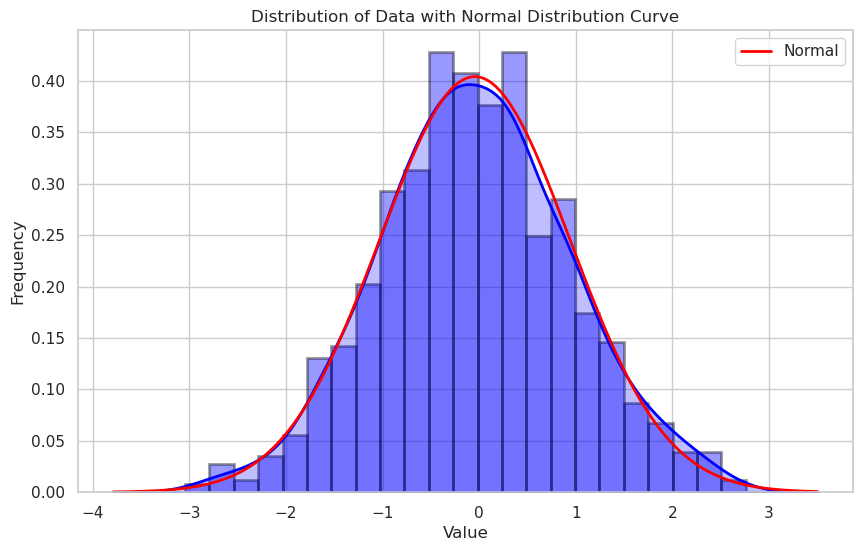

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate some example data
np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=1000)

# Plot the data with a normal distribution curve
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the distribution of the data
sns.distplot(data, hist=True, kde=True, fit=norm, color='blue', 
             hist_kws={'edgecolor':'black', 'linewidth': 2},
             kde_kws={'linewidth': 2, 'shade': True}, 
             fit_kws={"color":"red", "linewidth": 2, "label":"Normal"})

# Add labels and title
plt.title('Distribution of Data with Normal Distribution Curve')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.legend()
plt.show()

In [38]:
data

,Group_A,Group_B,Group_C
0,1.764052,1.555963,-2.532921
1,0.400157,1.892474,-2.711970
2,0.978738,0.577685,-0.953865
3,2.240893,1.104714,-1.958374
4,1.867558,1.228053,-1.080812
...,...,...,...
995,0.412871,1.097751,1.079177
996,-0.198399,2.401523,-1.907466
997,0.094192,1.158434,-1.192404
998,-1.147611,-0.141901,-2.212516


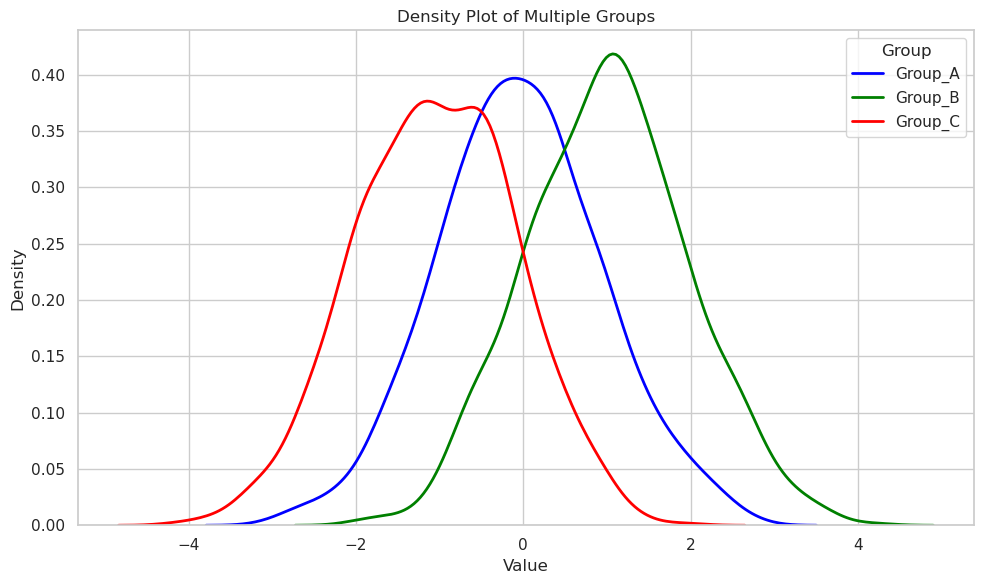

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate example data
np.random.seed(0)

# Create a DataFrame with multiple groups
data = pd.DataFrame({
    'Group_A': np.random.normal(loc=0, scale=1, size=1000),
    'Group_B': np.random.normal(loc=1, scale=1, size=1000),
    'Group_C': np.random.normal(loc=-1, scale=1, size=1000)
})

# Melt the DataFrame to long format
data_melted = data.melt(var_name='Group', value_name='Value')

# Plot KDE for each group in the same plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Plot KDE for each group
for group, color in zip(data.columns, ['blue', 'green', 'red']):
    sns.kdeplot(data=data[group], color=color, label=group, linewidth=2)

# Add labels and title
plt.title('Density Plot of Multiple Groups')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(title='Group')

# Show the plot
plt.tight_layout()
plt.show()

<Axes: xlabel='mean_log2', ylabel='Count'>

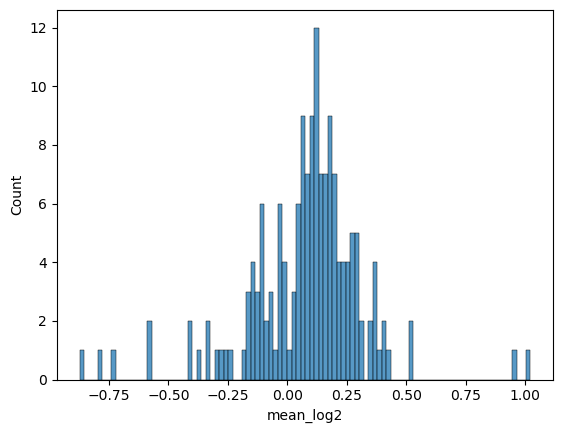

In [13]:
# sns.histplot(slea_controls['mean_log2'], bins=100)